# Assignment Module 2: Product Classification

The goal of this assignment is to implement a neural network that classifies smartphone pictures of products found in grocery stores. The assignment will be divided into two parts: first, you will be asked to implement from scratch your own neural network for image classification; then, you will fine-tune a pretrained network provided by PyTorch.


## Preliminaries: the dataset

The dataset you will be using contains natural images of products taken with a smartphone camera in different grocery stores:

<p align="center">
  <img src="https://github.com/marcusklasson/GroceryStoreDataset/raw/master/sample_images/natural/Granny-Smith.jpg" width="150">
  <img src="https://github.com/marcusklasson/GroceryStoreDataset/raw/master/sample_images/natural/Pink-Lady.jpg" width="150">
  <img src="https://github.com/marcusklasson/GroceryStoreDataset/raw/master/sample_images/natural/Lemon.jpg" width="150">
  <img src="https://github.com/marcusklasson/GroceryStoreDataset/raw/master/sample_images/natural/Banana.jpg" width="150">
  <img src="https://github.com/marcusklasson/GroceryStoreDataset/raw/master/sample_images/natural/Vine-Tomato.jpg" width="150">
</p>
<p align="center">
  <img src="https://github.com/marcusklasson/GroceryStoreDataset/raw/master/sample_images/natural/Yellow-Onion.jpg" width="150">
  <img src="https://github.com/marcusklasson/GroceryStoreDataset/raw/master/sample_images/natural/Green-Bell-Pepper.jpg" width="150">
  <img src="https://github.com/marcusklasson/GroceryStoreDataset/raw/master/sample_images/natural/Arla-Standard-Milk.jpg" width="150">
  <img src="https://github.com/marcusklasson/GroceryStoreDataset/raw/master/sample_images/natural/Oatly-Natural-Oatghurt.jpg" width="150">
  <img src="https://github.com/marcusklasson/GroceryStoreDataset/raw/master/sample_images/natural/Alpro-Fresh-Soy-Milk.jpg" width="150">
</p>

The products belong to the following 43 classes:
```
0.  Apple
1.  Avocado
2.  Banana
3.  Kiwi
4.  Lemon
5.  Lime
6.  Mango
7.  Melon
8.  Nectarine
9.  Orange
10. Papaya
11. Passion-Fruit
12. Peach
13. Pear
14. Pineapple
15. Plum
16. Pomegranate
17. Red-Grapefruit
18. Satsumas
19. Juice
20. Milk
21. Oatghurt
22. Oat-Milk
23. Sour-Cream
24. Sour-Milk
25. Soyghurt
26. Soy-Milk
27. Yoghurt
28. Asparagus
29. Aubergine
30. Cabbage
31. Carrots
32. Cucumber
33. Garlic
34. Ginger
35. Leek
36. Mushroom
37. Onion
38. Pepper
39. Potato
40. Red-Beet
41. Tomato
42. Zucchini
```

The dataset is split into training (`train`), validation (`val`), and test (`test`) set.

The following code cells download the dataset and define a `torch.utils.data.Dataset` class to access it. This `Dataset` class will be the starting point of your assignment: use it in your own code and build everything else around it.

In [1]:
import os
if not os.path.isdir("GroceryStoreDataset"):
    !git clone https://github.com/marcusklasson/GroceryStoreDataset.git
else:
    print("GroceryStoreDataset already present, skipping clone.")

GroceryStoreDataset already present, skipping clone.


In [2]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"  # let unsupported MPS ops fall back to CPU

from pathlib import Path
from PIL import Image
from torch import Tensor
from torch.utils.data import Dataset
from typing import List, Tuple

In [3]:
class GroceryStoreDataset(Dataset):

    def __init__(self, split: str, transform=None, verbose = False) -> None:
        super().__init__()

        self.root = Path("GroceryStoreDataset/dataset")
        self.split = split
        self.paths, self.labels = self.read_file()

        self.transform = transform
        self.verbose = verbose

    def __len__(self) -> int:                               # method returns int value
        return len(self.labels)

    def __getitem__(self, idx) -> Tuple[Tensor, int]:       # returns img and label
        img = Image.open(self.root / self.paths[idx])
        label = self.labels[idx]

        if self.transform:                                  # if transform is not None
            if self.verbose:
                print('Image original size:', np.array(img).shape)
            img = self.transform(img)

        return img, label

    def read_file(self) -> Tuple[List[str], List[int]]:
        paths = []
        labels = []

        with open(self.root / f"{self.split}.txt") as f:
            for line in f:
                # path, fine-grained class, coarse-grained class
                path, _, label = line.replace("\n", "").split(", ")
                paths.append(path), labels.append(int(label))

        return paths, labels

    def get_num_classes(self) -> int:
        return max(self.labels) + 1

### Class names

A fixed index → name map for the 43 coarse GroceryStoreDataset classes, defined once here so every plot downstream (sample images, class distribution, per-class accuracy, confusion matrix, predictions) can show human-readable labels.

In [4]:
# Class index -> human-readable name (43 GroceryStoreDataset classes)
CLASS_NAMES = [
    "Apple", "Avocado", "Banana", "Kiwi", "Lemon", "Lime", "Mango", "Melon",
    "Nectarine", "Orange", "Papaya", "Passion-Fruit", "Peach", "Pear", "Pineapple",
    "Plum", "Pomegranate", "Red-Grapefruit", "Satsumas", "Juice", "Milk", "Oatghurt",
    "Oat-Milk", "Sour-Cream", "Sour-Milk", "Soyghurt", "Soy-Milk", "Yoghurt",
    "Asparagus", "Aubergine", "Cabbage", "Carrots", "Cucumber", "Garlic", "Ginger",
    "Leek", "Mushroom", "Onion", "Pepper", "Potato", "Red-Beet", "Tomato", "Zucchini",
]

### Part 1: design your own network

Your goal is to implement a convolutional neural network for image classification and train it on `GroceryStoreDataset`. You should consider yourselves satisfied once you obtain a classification accuracy on the **validation** split of **around 60%**. You are free to achieve that however you want, except for a few rules you must follow:

- You **cannot** simply instantiate an off-the-self PyTorch network. Instead, you must construct your network as a composition of existing PyTorch layers. In more concrete terms, you can use e.g. `torch.nn.Linear`, but you **cannot** use e.g. `torchvision.models.alexnet`.

- Justify every *design choice* you make. Design choices include network architecture, training hyperparameters, and, possibly, dataset preprocessing steps. You can either (i) start from the simplest convolutional network you can think of and add complexity one step at a time, while showing how each step gets you closer to the target ~60%, or (ii) start from a model that is already able to achieve the desired accuracy and show how, by removing some of its components, its performance drops (i.e. an *ablation study*). You can *show* your results/improvements however you want: training plots, console-printed values or tables, or whatever else your heart desires: the clearer, the better.

Don't be too concerned with your network performance: the ~60% is just to give you an idea of when to stop. Keep in mind that a thoroughly justified model with lower accuracy will be rewarded **more** points than a poorly experimentally validated model with higher accuracy.

## Part 2: fine-tune an existing network

Your goal is to fine-tune a pretrained **ResNet-18** model on `GroceryStoreDataset`. Use the implementation provided by PyTorch, do not implement it yourselves! (i.e. exactly what you **could not** do in the first part of the assignment). Specifically, you must use the PyTorch ResNet-18 model pretrained on ImageNet-1K (V1). Divide your fine-tuning into two parts:

1. First, fine-tune the Resnet-18 with the same training hyperparameters you used for your best model in the first part of the assignment.
1. Then, tweak the training hyperparameters in order to increase the accuracy on the validation split of `GroceryStoreDataset`. Justify your choices by analyzing the training plots and/or citing sources that guided you in your decisions (papers, blog posts, YouTube videos, or whatever else you find enlightening). You should consider yourselves satisfied once you obtain a classification accuracy on the **validation** split **between 80 and 90%**.

# Part 1: Custom Convolutional Neural Network

## Setup

### Reproducibility and device

Random seeds are fixed across `torch`, `numpy`, and `random` (`fix_random(42)`) so that runs are repeatable. Training automatically selects the fastest available device: the Apple Silicon GPU (`mps`) on M-series Macs, CUDA on NVIDIA GPUs, or CPU as a fallback. Model weights are saved locally under the `weights/` directory.

In [5]:
import torch
print("Using torch", torch.__version__)

import numpy as np
import random
import copy

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn

import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms as T
from torch.optim import Adam


def fix_random(seed: int) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    #torch.backends.cudnn.benchmark = False
    #torch.backends.cudnn.deterministic = True

fix_random(42)

Using torch 2.7.0


### Dataset Inspection

Random training samples are displayed to get a visual sense of the data: lighting conditions, camera distances, backgrounds, and product variety across the 43 classes.

Total Number of Classes: 43 



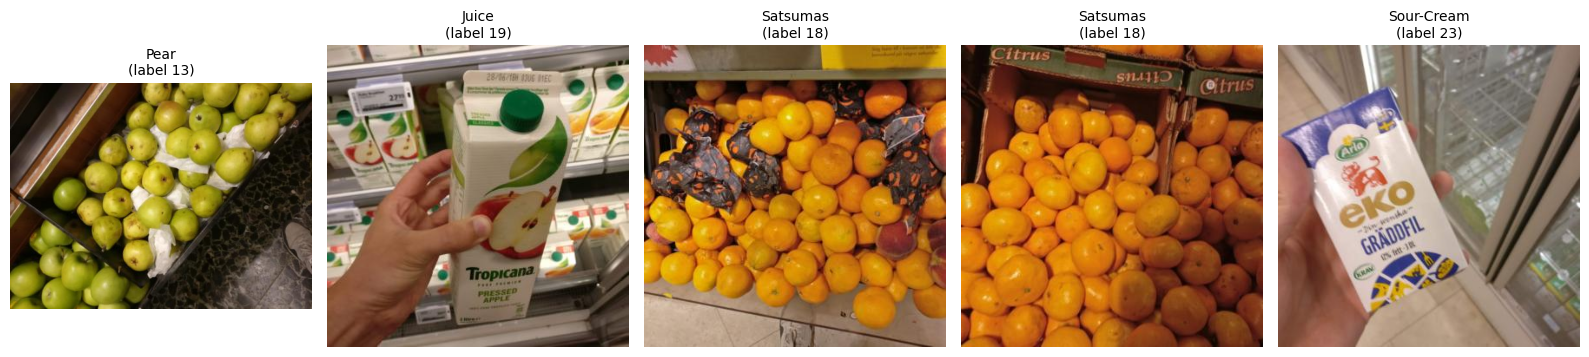

In [6]:
tsfms = T.Compose([T.ToTensor()])
# getting path and labels of the datasets and applying the transforms
sample_ds = GroceryStoreDataset("train", transform=tsfms, verbose=False)
print('Total Number of Classes:', sample_ds.get_num_classes(), '\n')

plt.figure(figsize=(16, 4))
for i in range(5):
    index = np.random.randint(0, len(sample_ds.paths))
    label = sample_ds.labels[index]

    plt.subplot(1, 5, i + 1)
    # show the human-readable class name instead of a bare numeric label
    plt.title(f"{CLASS_NAMES[label]}\n(label {label})", fontsize=10)
    plt.axis('off')
    # Displaying the image (3, H, W) -> (H, W, 3)
    plt.imshow(sample_ds[index][0].permute(1, 2, 0))

plt.tight_layout()
plt.show()

### Class Distribution

The 43 classes are not equally represented. Plotting the per-class image counts for each split exposes the imbalance and any classes that are under-represented (or missing) in a split. This context matters when reading the per-class accuracy of the final models, and is a reason to look beyond a single overall-accuracy number.

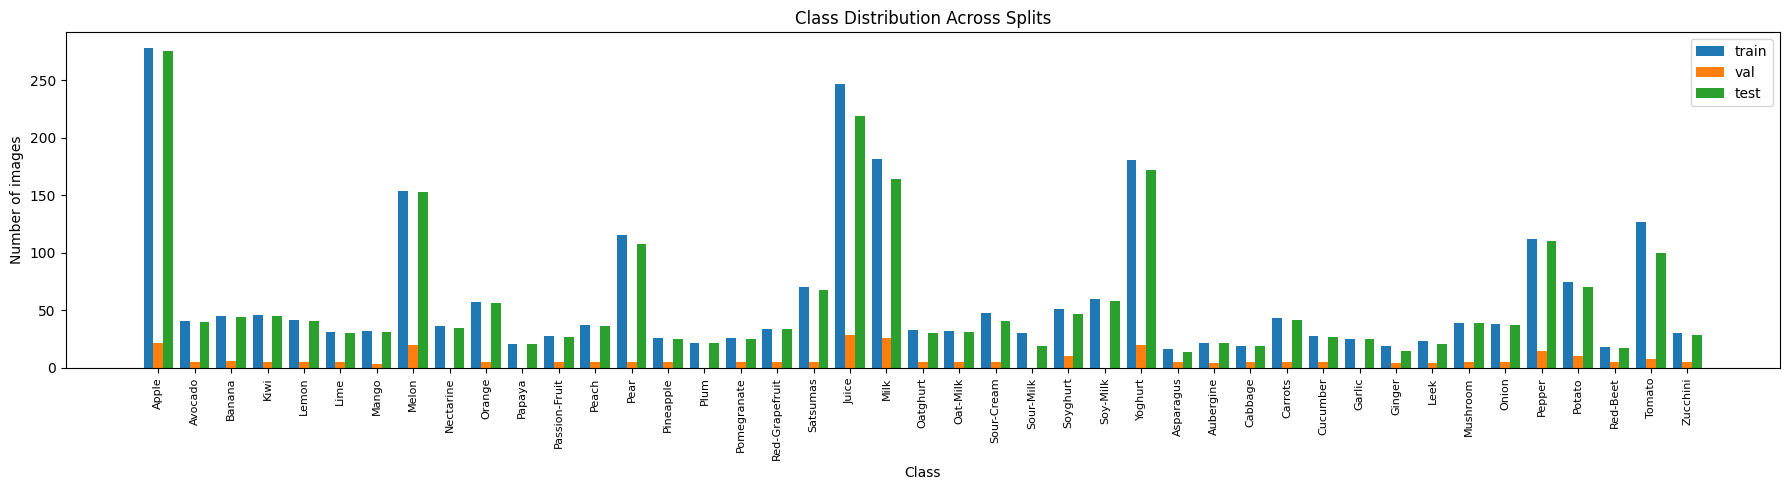

In [7]:
def plot_class_distribution(splits=("train", "val", "test")):
    """Grouped bar chart of per-class image counts across the dataset splits."""
    n = len(CLASS_NAMES)
    x = np.arange(n)
    width = 0.27
    plt.figure(figsize=(18, 5))
    for i, split in enumerate(splits):
        # only the labels are needed here, so no transform is required
        counts = np.bincount(GroceryStoreDataset(split).labels, minlength=n)
        plt.bar(x + i * width, counts, width=width, label=split)
    plt.xticks(x + width, CLASS_NAMES, rotation=90, fontsize=8)
    plt.xlabel("Class")
    plt.ylabel("Number of images")
    plt.title("Class Distribution Across Splits")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_class_distribution()

### Learning Rate Scheduler

A **OneCycleLR** scheduler is used during training (with the **Adam** optimizer). It starts at a low learning rate (warmup phase), ramps up to the peak LR for faster convergence, then anneals toward zero, allowing the optimizer to settle into sharper, lower-loss minima at the end of training.

**Why such a high peak LR?** Because the scheduler warms up *before* reaching the peak and decays *after* it, we can afford an aggressive peak that would diverge under a fixed learning rate: the warmup eases the optimizer in and the long decay lets it settle (the "super-convergence" effect, Smith & Topin, 2018). The shallow Models 1–4 therefore use `max_lr = 1e-2`; for the deeper **residual** network and the **ResNet** fine-tuning the peak is lowered (`1e-3`, and `1e-4` for full fine-tuning), since those models showed instability at the higher value.

**How far it decays.** `final_div_factor` sets the end-of-training LR (e.g. `10000` takes `1e-2` down to `1e-6`), so each run finishes at a near-zero LR for a clean final descent.

The per-epoch learning rate is recorded during training and **overlaid on the training curves** (see the evaluation function below), so the schedule can be read directly against the loss and accuracy it drives. A linear-warmup + linear-decay variant (`WarmupScheduler`) is also included for reference, but the experiments below all use OneCycleLR.

In [8]:
from torch.optim import Optimizer
from torch.optim.lr_scheduler import _LRScheduler
from torch.optim.lr_scheduler import OneCycleLR, ReduceLROnPlateau

class WarmupScheduler(_LRScheduler):
    def __init__(self, optimizer: Optimizer, warmup_steps: int, total_steps: int, last_epoch: int = -1):
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps

        super(WarmupScheduler, self).__init__(optimizer, last_epoch)


    def get_lr(self):
        if self.last_epoch < self.warmup_steps:
            # Linear warmup phase
            return [base_lr * (self.last_epoch + 1) / self.warmup_steps for base_lr in self.base_lrs]
        else:
            # Decay phase
            return [base_lr * (self.total_steps - self.last_epoch) / (self.total_steps - self.warmup_steps) for base_lr in self.base_lrs]

In [9]:
import os
from tqdm.notebook import tqdm

# Local directory to store model weights (replaces Google Drive used on Colab)
WEIGHTS_DIR = "weights"
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Select the best available device:
#   "mps"  -> Apple Silicon GPU
#   "cuda" -> NVIDIA GPU
#   "cpu"  -> fallback
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


### Training Loop

The training loop provides:
- **Best-weight snapshotting**: the weights from the epoch with the highest validation accuracy are saved to `weights/` and are the ones evaluated/reported — so each model is judged at its best checkpoint, not necessarily its final epoch.
- **Early stopping** with best-weight restoration is supported through the `patience` argument, but it is **disabled in this study** (`PATIENCE = None`): every model trains for the same fixed budget of **50 epochs** (30 for the ResNet full fine-tune, which converges faster) so that architectures are compared on equal footing rather than stopping at different points.
- Per-epoch logging of train/validation loss and accuracy, plus recording of the per-epoch learning rate for the schedule overlay.
- **Scheduler step after each batch** — required by OneCycleLR, whose `total_steps = epochs × batches_per_epoch`.

In [10]:
import copy

def ncorrect(scores, y):
    y_pred = torch.argmax(scores, -1)
    return (y_pred == y).sum()

def train_loop(model, train_dl, val_dl, criterion, opt, epochs, scheduler=None, patience=None, verbose=False):
    best_val_acc = 0.0
    patience_counter = 0              # Counter to track how long since validation loss improvement
    best_epoch = -1
    best_weights = copy.deepcopy(model.state_dict()) # snapshot of best weights so far

    # store for return
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    lrs = []                      # per-epoch learning rate, to plot the schedule

    for epoch in tqdm(range(epochs)):
        model.train()                 # Set the model to training mode
        lrs.append(max(g['lr'] for g in opt.param_groups))   # LR at the start of the epoch

        train_loss = 0.0
        train_acc = 0.0
        train_samples=0               # num of samples

        for train_data in train_dl:
            imgs = train_data[0].to(device)
            labels = train_data[1].to(device)

            output_scores = model(imgs)
            loss = criterion(output_scores, labels)

            train_loss += loss.item()*imgs.shape[0]               # mul by batch size
            train_samples += imgs.shape[0]                        # update seen samples
            train_acc += ncorrect(output_scores, labels).item()   # item converts single el pytorch tensor to standard python num

            opt.zero_grad()         # Reset gradients making sure they are not accumulated from previous batches
            loss.backward()         # Backpropagation
            opt.step()              # Update weights
            if scheduler != None:
              scheduler.step()        # Update learning rate

        train_loss /= train_samples
        train_acc /= train_samples

        # after each epoch, validate the model on validation set
        val_loss, val_acc = validate(model, val_dl, criterion)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        if verbose and ((epoch+1)%5==0 or epoch==0 or epoch==epochs ):
            print(f'Epoch {epoch+1}/{epochs}, Training Loss: {train_loss:.4f} - Training Acc: {train_acc:.4f}, Validation Loss: {val_loss:.4f} - Validation Acc: {val_acc:.4f}')

        # check for improvement in validation loss
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())                                            # snapshot the best weights
            torch.save(best_weights, os.path.join(WEIGHTS_DIR, "weights.pth"))                          # saving the best weights
            best_epoch = epoch
            if patience != None:
              patience_counter = 0      # reset counter
        else:
            if patience != None:
              patience_counter += 1

        #scheduler.step(val_loss)       # for ReduceLROnPlateau

        # early stopping with weight restore
        # if patience is None then no early stopping
        if patience != None and patience_counter >= patience:
            if verbose:
                print(f'Early stopping at epoch {epoch+1}')
            model.load_state_dict(best_weights)
            break

    if verbose:
        print()
        print(f"Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch+1}")

    # expose the LR trace to evaluate() without changing this function's return signature
    global LAST_TRAIN_LRS
    LAST_TRAIN_LRS = lrs

    # returns losses and accuracies for plotting
    return best_val_acc, best_weights, best_epoch, train_losses, val_losses, train_accuracies, val_accuracies

def validate(model, val_dl, criterion):
    model.eval()  # Set model to evaluation mode
    val_loss = 0.0
    val_acc = 0.0
    val_samples = 0
    with torch.no_grad():  # no need to calculate gradients for validation
        for val_data in val_dl:
            imgs = val_data[0].to(device)
            labels = val_data[1].to(device)
            val_scores = model(imgs)
            loss = criterion(val_scores, labels)
            val_loss += loss.item() * imgs.shape[0]
            val_samples += imgs.shape[0]
            val_acc += ncorrect(val_scores, labels).item()

    val_loss /= val_samples
    val_acc /= val_samples

    return val_loss, val_acc

### Evaluation Function

The `evaluate` function computes test-set accuracy and produces diagnostic plots:
- **Training curves**: loss and accuracy over epochs, with the **learning-rate schedule overlaid** on a secondary axis (dashed grey). This makes the OneCycleLR warmup/decay visible and directly readable against the loss it drives. The best-validation-accuracy epoch is marked with a vertical dashed line.
- **Per-class accuracy** bar chart, **sorted ascending and labelled with class names** so the hardest classes are easy to spot (enabled with `plot_confusion_matrix=True`).
- **Confusion matrix** heatmap (43 × 43, with class-named axes), **row-normalized** so each true-class row sums to 1 — raw counts are dominated by class imbalance and hide the errors, whereas the normalized view puts every class on a common 0–1 scale. Per-cell annotations omitted, too dense to read at this scale.

Each call also records its validation curves into `MODEL_RESULTS`, so the models can be overlaid for comparison at the end of Part 1.

In [11]:
import pandas as pd
import seaborn as sn

# Filled in by train_loop(): per-epoch learning-rate trace of the most recent run, so
# evaluate() can overlay the schedule on the training curves without changing train_loop's
# return signature. Also serves as the default when `lrs` is not passed explicitly.
LAST_TRAIN_LRS = []

# Filled in by evaluate(): model_name -> recorded curves, used for the comparison plot below.
MODEL_RESULTS = {}


def _plot_lr_overlay(ax, lrs, epochs_axis):
    """Overlay the LR schedule on `ax` using a twin y-axis. Returns (handles, labels)."""
    lines, labels = ax.get_legend_handles_labels()
    if lrs is not None and len(lrs) == len(epochs_axis):
        ax_lr = ax.twinx()
        (line,) = ax_lr.plot(epochs_axis, lrs, color='grey', linestyle='dashed', label='Learning Rate')
        ax_lr.set_ylabel('Learning Rate')
        ax_lr.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
        lines, labels = lines + [line], labels + ['Learning Rate']
    return lines, labels


def evaluate(model, test_dl, n_classes, train_losses, val_losses, train_accuracies, val_accuracies,
             plot_confusion_matrix=False, model_name="Model", lrs=None, class_names=None):
    model.eval()
    confusion_matrix = torch.zeros(n_classes, n_classes, dtype=torch.int)

    with torch.no_grad():
        for test_data in test_dl:
            imgs = test_data[0].to(device)
            labels = test_data[1].to(device)
            test_scores = model(imgs)
            preds = torch.argmax(test_scores, -1)
            for lbl, pred in zip(labels.view(-1), preds.view(-1)):
                confusion_matrix[lbl.int(), pred.int()] += 1

    test_acc = (torch.diagonal(confusion_matrix).sum() / confusion_matrix.sum()).item()
    print(f'\nTest Set Accuracy [{model_name}]: {test_acc:.4f}')

    # Record this run so the models can be overlaid/compared later (keyed by name -> reruns overwrite)
    MODEL_RESULTS[model_name] = {
        'val_accuracies': list(val_accuracies),
        'val_losses': list(val_losses),
        'test_acc': test_acc,
        'best_val_acc': max(val_accuracies) if val_accuracies else float('nan'),
    }
    # Persist the comparison dict so it survives a kernel restart
    # (reloaded by the checkpoint-cache cell). Defined there; resolved at call time.
    _persist_model_results()

    # Axis labels for the classes (fall back to indices when names are not provided)
    ticks = class_names if class_names is not None else list(range(n_classes))

    if plot_confusion_matrix:
        # Per-class accuracy, sorted ascending so the hardest classes stand out on the left
        per_class_acc = (torch.diagonal(confusion_matrix).float() /
                         confusion_matrix.sum(dim=1).float().clamp(min=1)).numpy()
        order = np.argsort(per_class_acc)
        plt.figure(figsize=(16, 5))
        plt.bar(range(n_classes), per_class_acc[order], color='steelblue')
        plt.axhline(y=test_acc, color='r', linestyle='--', label=f'Overall accuracy: {test_acc:.2f}')
        plt.xticks(range(n_classes), [ticks[i] for i in order], rotation=90, fontsize=8)
        plt.ylabel('Accuracy')
        plt.title(f'{model_name} — Per-Class Accuracy (sorted)')
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Confusion matrix heatmap, row-normalized so each true-class row sums to 1.
        # Raw counts are dominated by class imbalance (big classes swamp the scale and
        # wash out the off-diagonal errors); normalizing puts every class on a 0-1 scale
        # so misclassifications are visible. annotations omitted: 43x43 is too dense to read.
        cm_norm = (confusion_matrix.float() /
                   confusion_matrix.sum(dim=1, keepdim=True).float().clamp(min=1))
        conf_df = pd.DataFrame(cm_norm.numpy(), index=ticks, columns=ticks)
        plt.figure(figsize=(14, 12))
        sn.heatmap(conf_df, annot=False, cmap='Blues', vmin=0, vmax=1,
                   xticklabels=True, yticklabels=True,
                   cbar_kws={'label': 'Fraction of true-class samples'})
        plt.xlabel('Predicted Class')
        plt.ylabel('True Class')
        plt.title(f'{model_name} — Confusion Matrix (row-normalized)')
        plt.tight_layout()
        plt.show()

    # Training curves with the learning-rate schedule overlaid on a twin axis
    if lrs is None:
        lrs = LAST_TRAIN_LRS
    best_val_acc = max(val_accuracies)
    best_epoch = val_accuracies.index(best_val_acc)
    epochs_axis = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — Training Curves', fontsize=13, fontweight='bold')

    # Loss
    axes[0].plot(epochs_axis, train_losses, label='Train Loss')
    axes[0].plot(epochs_axis, val_losses, label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss over Epochs')
    axes[0].grid(True)
    lines, labels = _plot_lr_overlay(axes[0], lrs, epochs_axis)
    axes[0].legend(lines, labels, loc='upper right')

    # Accuracy
    axes[1].plot(epochs_axis, train_accuracies, label='Train Accuracy')
    axes[1].plot(epochs_axis, val_accuracies, label='Val Accuracy')
    axes[1].axvline(x=best_epoch + 1, color='r', linestyle='--', alpha=0.7,
                    label=f'Best val acc: {best_val_acc:.4f} (epoch {best_epoch + 1})')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy over Epochs')
    axes[1].grid(True)
    lines, labels = _plot_lr_overlay(axes[1], lrs, epochs_axis)
    axes[1].legend(lines, labels, loc='lower right')

    plt.tight_layout()
    plt.show()

    return test_acc


def compare_models(models_data=None, metric='val_accuracy'):
    """Overlay validation curves for multiple models on a single plot.

    Args:
        models_data: list of dicts, each with keys 'name' and either 'val_accuracies'
                     or 'val_losses'. If None, every model recorded in MODEL_RESULTS is used.
        metric: 'val_accuracy' or 'val_loss'.
    """
    if models_data is None:
        models_data = [{'name': k, **v} for k, v in MODEL_RESULTS.items()]
    plt.figure(figsize=(10, 5))
    for m in models_data:
        values = m['val_accuracies'] if metric == 'val_accuracy' else m['val_losses']
        plt.plot(range(1, len(values) + 1), values, label=m['name'])
    plt.xlabel('Epoch')
    ylabel = 'Accuracy' if metric == 'val_accuracy' else 'Loss'
    plt.ylabel(ylabel)
    plt.title(f'Model Comparison — Validation {ylabel}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [12]:
# Checkpoint cache____________________________________________________
#
# Persists each trained model and its training history to disk 
# force=True to retrain a model from scratch.
# ----------------------------------------------------------------------
import json

RUN_CACHE_DIR = "runs"
os.makedirs(RUN_CACHE_DIR, exist_ok=True)
MODEL_RESULTS_PATH = os.path.join(RUN_CACHE_DIR, "model_results.json")


def _persist_model_results():
    with open(MODEL_RESULTS_PATH, "w") as f:
        json.dump(MODEL_RESULTS, f, indent=2)


# Reload the comparison dict from a previous session (if any) so the
# comparison plots work without re-running every model cell.
if os.path.exists(MODEL_RESULTS_PATH):
    with open(MODEL_RESULTS_PATH) as f:
        MODEL_RESULTS.update(json.load(f))
    print(f"[cache] restored MODEL_RESULTS for {list(MODEL_RESULTS)}")


def fit_cached(model, tag, train_dl, val_dl, criterion, opt, epochs,
               scheduler=None, patience=None, verbose=False, force=False):
    """Drop-in replacement for train_loop() that caches results to disk.

    If a checkpoint for `tag` exists (and force=False), load its weights into
    `model` and return the cached history instead of training. Otherwise train
    normally, then save both the weights and the history under `tag`.

    Returns the same 7-tuple as train_loop:
        (best_val_acc, best_weights, best_epoch,
         train_losses, val_losses, train_accuracies, val_accuracies)
    """
    global LAST_TRAIN_LRS
    weights_path = os.path.join(WEIGHTS_DIR, f"{tag}.pth")
    history_path = os.path.join(RUN_CACHE_DIR, f"{tag}.json")

    if not force and os.path.exists(weights_path) and os.path.exists(history_path):
        model.load_state_dict(torch.load(weights_path, map_location=device))
        with open(history_path) as f:
            h = json.load(f)
        LAST_TRAIN_LRS = h["lrs"]
        print(f"[cache] loaded '{tag}' from {weights_path} \u2014 skipping training "
              f"(best val acc {h['best_val_acc']:.4f})")
        return (h["best_val_acc"], model.state_dict(), h["best_epoch"],
                h["train_losses"], h["val_losses"],
                h["train_accuracies"], h["val_accuracies"])

    results = train_loop(model, train_dl=train_dl, val_dl=val_dl, criterion=criterion,
                         opt=opt, epochs=epochs, scheduler=scheduler,
                         patience=patience, verbose=verbose)
    best_val_acc, best_weights, best_epoch, train_losses, val_losses, train_accuracies, val_accuracies = results

    torch.save(best_weights, weights_path)
    with open(history_path, "w") as f:
        json.dump({"best_val_acc": best_val_acc, "best_epoch": best_epoch,
                   "train_losses": train_losses, "val_losses": val_losses,
                   "train_accuracies": train_accuracies,
                   "val_accuracies": val_accuracies,
                   "lrs": LAST_TRAIN_LRS}, f)
    print(f"[cache] saved '{tag}' -> {weights_path}")
    return results


[cache] restored MODEL_RESULTS for ['Model 1 — Single-Stage', 'Model 2 — Two-Stage', 'Model 3 — Three-Stage', 'Model 4 — Deeper (11 layers)', 'Model 5 — Dropout', 'Model 6 — Residual', 'Ablation — No BatchNorm', 'Ablation — No LR Scheduler', 'ResNet-18 — Head Only', 'ResNet-18 — Full Fine-Tune']


### Data Augmentation

Training images are augmented with **random cropping** (224 × 224) and **random horizontal flips**; validation and test sets use a deterministic **center crop** (224 × 224) so evaluation is repeatable.

**Why 224 × 224?** It is the native input resolution ResNet-18 was pretrained on (ImageNet), so reusing it keeps Part 1 and Part 2 directly comparable and feeds the pretrained backbone inputs in its expected size. The source photos (~348²) are *larger* than 224, so we **crop rather than downscale**: this preserves native pixel detail, and on the training set the random crop position adds translation jitter — the network sees a slightly different sub-view of the product every epoch, enlarging the effective dataset and encouraging spatial invariance. Horizontal flipping is label-preserving for these products (a mirrored banana is still a banana).

**Normalization.** Images are finally normalized with the **ImageNet mean/std** — the input distribution the pretrained ResNet-18 backbone (Part 2) expects. The from-scratch models (Part 1) share the same dataloaders and simply benefit from zero-centered inputs.

In [13]:
from torch.utils.data import DataLoader

# ImageNet statistics: inputs are normalized to the distribution the pretrained ResNet-18
# (Part 2) expects. The from-scratch models (Part 1) share these loaders and simply benefit
# from zero-centered inputs.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tsfms = T.Compose([T.RandomCrop(224),                     # random crop -> data augmentation (translation jitter)
                         T.RandomHorizontalFlip(),              # label-preserving flip -> data augmentation
                         T.ToTensor(),
                         T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
test_tsfms = T.Compose([T.CenterCrop(224),                     # deterministic crop for repeatable evaluation
                        T.ToTensor(),
                        T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

train_ds = GroceryStoreDataset("train", transform=train_tsfms, verbose=False)
test_ds = GroceryStoreDataset("test", transform=test_tsfms, verbose=False)
val_ds = GroceryStoreDataset("val", transform=test_tsfms, verbose=False)

# batch_size=32: fits comfortably on a laptop GPU/MPS while keeping BatchNorm statistics stable
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)    # reshuffled each epoch -> fresh random crops per image
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=32, shuffle=False)

## Model Architecture Exploration

This section documents a **structured incremental design study**. The protocol is simple:

- Start from the **simplest possible network** as a baseline
- Add **one component at a time**, keeping everything else identical
- If the change improves validation accuracy → **keep it** in all subsequent models
- If the change does not help → **discard it**, and let the experiment explain why

Every model in this study builds directly on the previous one. By the time we reach the best model, each component it contains has been individually justified by an experiment showing that removing it hurts performance.

**Components present in all models from the start** (established as baseline, validated by ablation later):
- **Convolutional "stages" (VGG-style):** each stage is one or more `Conv 3×3 → BatchNorm → ReLU` units followed by a `2×2 MaxPool`. The channel width **doubles** (64 → 128 → 256 → 512) as the spatial resolution is **halved** — the standard VGG trade of spatial detail for semantic depth (Simonyan & Zisserman, 2014). Stacking small 3×3 convolutions keeps the parameter cost low while growing the receptive field.
- **Batch normalization** after every convolutional layer: stabilizes activations and accelerates convergence (the ablation below confirms it).
- **Global average pooling** before the classifier head, *instead of* flatten + a large fully-connected layer: it collapses each feature map to a single number, so the classifier's size is independent of input resolution and the parameter count stays small — and it adds robustness to *where* in the frame the product appears. The idea comes from Network-in-Network (Lin et al., 2014) and Inception/GoogLeNet (Szegedy et al., 2015).
- **OneCycleLR scheduler** + **Adam optimizer**: warmup + decay for reliable convergence and a high usable peak LR (see above).
- **Label smoothing (0.1)** in the cross-entropy loss: the target for the correct class is softened to 0.9 (the remaining 0.1 is spread over the other classes), which discourages over-confident logits, acts as a light regularizer, and tends to improve generalization and calibration (Szegedy et al., 2016). It is held fixed across all models so it never confounds the architecture comparison.

---

**Initial reference model (discarded):** an early model with ~20 M parameters, drawing on VGG-style stage repetition and an Inception-style Global Average Pooling head, achieved a validation accuracy of 0.7196. It was discarded in favour of the step-by-step approach below, which reaches comparable performance with far fewer parameters and a fully traceable design trajectory.

**Observation on spatial extent:** product items typically occupy the central portion of the image and are often presented in uniform stacks. A very large receptive field spanning the full image is therefore unlikely to add strong discriminative power, motivating the use of compact architectures.

### Model 1, Single-Stage Classifier

As the baseline, the network is reduced to its bare minimum: a single convolutional stage followed by global average pooling and a linear classifier.

In [14]:
class ClassifierOneStage(nn.Module):          # subclassing nn.Module
    def __init__(self, n_classes, dropout=0.15):
        super().__init__()

        self.features_extractor = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )


        # Global Average Pooling classifier averaging out Spatial Dimensions taking inspiration from Inception V1
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),   # Averages height and width dimensions
            nn.Flatten(),
            nn.Linear(64, n_classes)       # Outputs the class scores
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features_extractor(x)    # Pass input through the feature extractor
        x = self.classifier(x)
        return x

In [15]:
print('Steps in one epoch:',len(train_ds)/32)

Steps in one epoch: 82.5


In [16]:
N_CLASSES = train_ds.get_num_classes()
model_one = ClassifierOneStage(
    N_CLASSES
).to(device)


# using pytorch OneCycleLR
EPOCHS = 50
PATIENCE = None                                                                         # no early stopping
OPTIMIZER = torch.optim.Adam(model_one.parameters(), lr=0.01)                           # trying higher lr since using the learning rate scheduler
SCHEDULER = OneCycleLR(OPTIMIZER, max_lr=0.01, total_steps=EPOCHS * len(train_dl), final_div_factor=10000) # from 1e-2 to 1e-6
CRITERION = nn.CrossEntropyLoss(label_smoothing = 0.1)                                  # label smoothing -> correct will be 0.9

results = fit_cached(
    model_one, tag="model1_single",
    train_dl=train_dl,
    val_dl=val_dl,
    criterion=CRITERION,  # loss
    opt=OPTIMIZER,
    scheduler=SCHEDULER,
    epochs=EPOCHS,
    patience=PATIENCE,
    verbose=True          # print progress
)

best_val_acc, best_weights, best_epoch, train_losses, val_losses, train_accuracies, val_accuracies = results

[cache] loaded 'model1_single' from weights/model1_single.pth — skipping training (best val acc 0.5811)



Test Set Accuracy [Model 1 — Single-Stage]: 0.5835


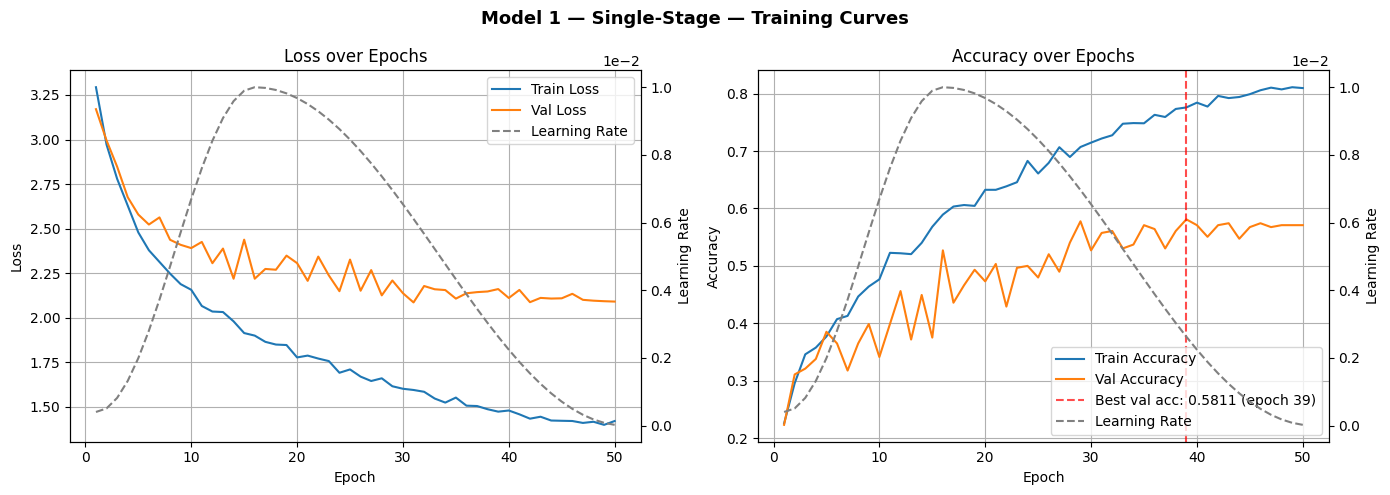

In [17]:
# Evaluate Model
test_acc = evaluate(model=model_one, test_dl=test_dl, n_classes=N_CLASSES, train_losses=train_losses, val_losses=val_losses, train_accuracies=train_accuracies, val_accuracies=val_accuracies, model_name="Model 1 — Single-Stage")

**Result**: the single-stage baseline scores **0.6133** on the test set (validation **0.5811**), just short of the 0.60 validation target. With only ~41 k parameters the architecture is too shallow to capture discriminative features across 43 classes.

In [18]:
total_params = sum(p.numel() for p in model_one.parameters() if p.requires_grad)
print(f"Total trainable parameters of the model with one stage: {total_params}")
print()

Total trainable parameters of the model with one stage: 41771



In [19]:
del(model_one)  # free up memory

### Model 2, Two-Stage Classifier

A second convolutional stage is added, doubling network depth and expanding the number of learned feature channels.

In [20]:
class ClassifierTwoStages(nn.Module):          # subclassing nn.Module
    def __init__(self, n_classes, dropout=0.15):
        super().__init__()

        self.features_extractor = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )


        # Fully connected classifier averaging out dimensions
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),   # Averages height and width dimensions
            nn.Flatten(),
            nn.Linear(128, n_classes)       # Outputs the class scores
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features_extractor(x)    # Pass input through the feature extractor
        x = self.classifier(x)
        return x


In [21]:
N_CLASSES = train_ds.get_num_classes()
model_two = ClassifierTwoStages(
    N_CLASSES
).to(device)

total_params = sum(p.numel() for p in model_two.parameters() if p.requires_grad)
print(f"Total trainable parameters of the model with two stages: {total_params}")
print()


# using pytorch OneCycleLR
EPOCHS = 50
PATIENCE = None                                                                         # no early stopping
OPTIMIZER = torch.optim.Adam(model_two.parameters(), lr=0.01)                           # trying higher lr since using the learning rate scheduler
SCHEDULER = OneCycleLR(OPTIMIZER, max_lr=0.01, total_steps=EPOCHS * len(train_dl), final_div_factor=1000) # from 1e-2 to 1e-5
CRITERION = nn.CrossEntropyLoss(label_smoothing = 0.1)                                  # label smoothing -> correct will be 0.9

results = fit_cached(
    model_two, tag="model2_two_stage",
    train_dl=train_dl,
    val_dl=val_dl,
    criterion=CRITERION,  # loss
    opt=OPTIMIZER,
    scheduler=SCHEDULER,
    epochs=EPOCHS,
    patience=PATIENCE,
    verbose=True          # print progress
)

best_val_acc, best_weights, best_epoch, train_losses, val_losses, train_accuracies, val_accuracies = results

Total trainable parameters of the model with two stages: 266475

[cache] loaded 'model2_two_stage' from weights/model2_two_stage.pth — skipping training (best val acc 0.6419)



Test Set Accuracy [Model 2 — Two-Stage]: 0.7505


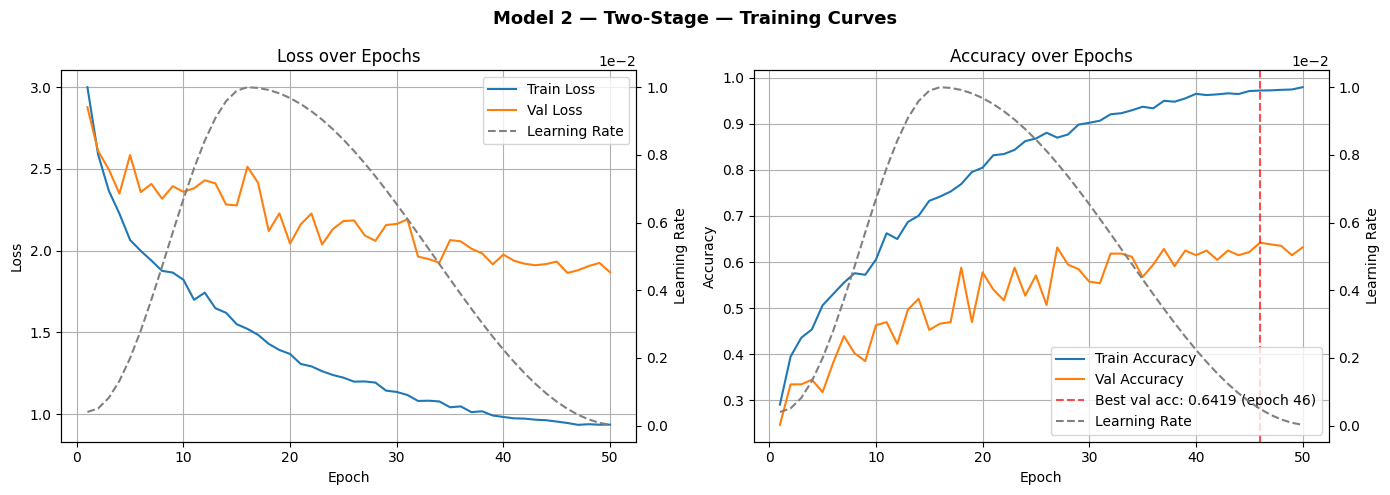

In [22]:
# Evaluate Model
best_val_acc, best_weights, best_epoch, train_losses, val_losses, train_accuracies, val_accuracies = results
test_acc = evaluate(model=model_two, test_dl=test_dl, n_classes=N_CLASSES, train_losses=train_losses, val_losses=val_losses, train_accuracies=train_accuracies, val_accuracies=val_accuracies, model_name="Model 2 — Two-Stage")

**Result**: validation accuracy improves to 0.6419 (test: 0.7477) with only ~260 k parameters. The loss curves confirm steady convergence; the OneCycleLR scheduler visibly helps the optimizer settle into lower optima in the final phase of training.

In [23]:
del(model_two)  # free up memory

### Model 3, Three-Stage Classifier

A third convolutional stage is added, further increasing depth and the network's capacity to learn hierarchical features.

In [24]:
class ClassifierThreeStages(nn.Module):          # subclassing nn.Module
    def __init__(self, n_classes, dropout=0.15):
        super().__init__()

        #Repetition of stages taking inspiration from VGG.
        #Adding BatchNorm for faster convergence and averaging out spatial dimensions.
        self.features_extractor = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        # Global Average Pooling classifier averaging out Spatial Dimensions taking inspiration from Inception V1
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),   # Averages height and width dimensions
            nn.Flatten(),
            nn.Linear(256, n_classes)       # Outputs the class scores
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features_extractor(x)    # Pass input through the feature extractor
        x = self.classifier(x)
        return x


Total trainable parameters of the model with three stages: 1748843

[cache] loaded 'model3_three_stage' from weights/model3_three_stage.pth — skipping training (best val acc 0.6689)

Test Set Accuracy [Model 3 — Three-Stage]: 0.7541


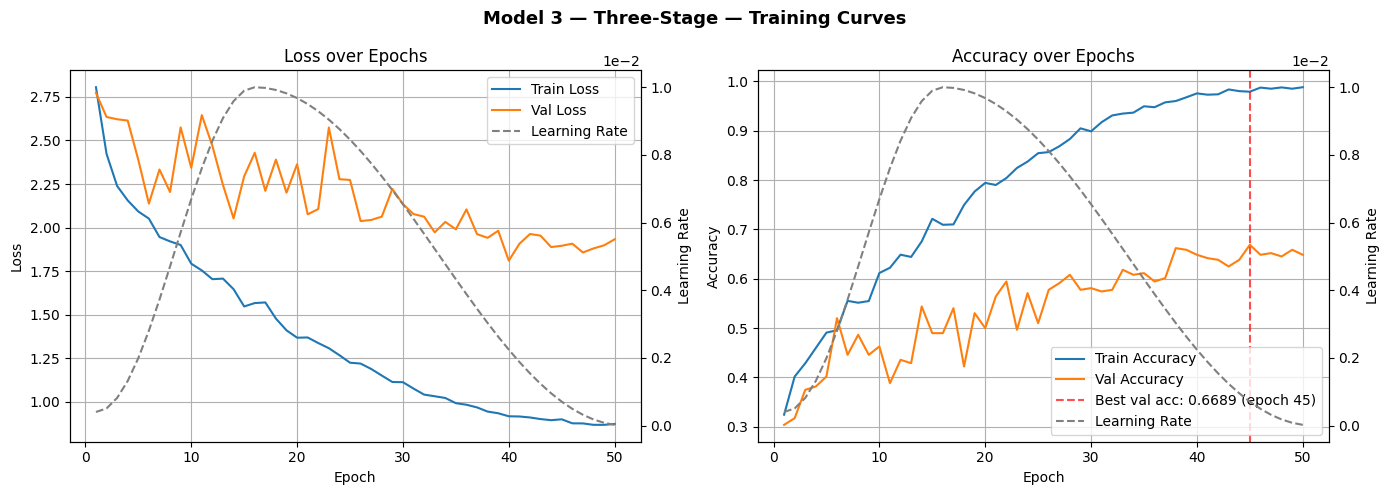

In [25]:
N_CLASSES = train_ds.get_num_classes()
model_three = ClassifierThreeStages(
    N_CLASSES
).to(device)

total_params = sum(p.numel() for p in model_three.parameters() if p.requires_grad)
print(f"Total trainable parameters of the model with three stages: {total_params}")
print()


# using pytorch OneCycleLR
EPOCHS = 50
PATIENCE = None                                                                             # no early stopping
OPTIMIZER = torch.optim.Adam(model_three.parameters(), lr=0.01)                             # trying higher lr since using the learning rate scheduler
SCHEDULER = OneCycleLR(OPTIMIZER, max_lr=0.01, total_steps=EPOCHS * len(train_dl), final_div_factor=10000)    # from 1e-2 to 1e-6
CRITERION = nn.CrossEntropyLoss(label_smoothing = 0.1)                                      # label smoothing -> correct will be 0.9

results = fit_cached(
    model_three, tag="model3_three_stage",
    train_dl=train_dl,
    val_dl=val_dl,
    criterion=CRITERION,  # loss
    opt=OPTIMIZER,
    scheduler=SCHEDULER,
    epochs=EPOCHS,
    patience=PATIENCE,
    verbose=True          # print progress
)

best_val_acc, best_weights, best_epoch, train_losses, val_losses, train_accuracies, val_accuracies = results

# Evaluate Model
test_acc = evaluate(model=model_three, test_dl=test_dl, n_classes=N_CLASSES, train_losses=train_losses, val_losses=val_losses, train_accuracies=train_accuracies, val_accuracies=val_accuracies, model_name="Model 3 — Three-Stage")

**Result**: a third stage pushes validation accuracy to 0.6689 (test: 0.7602). Performance continues to scale with depth at this parameter count (~1.75 M parameters).

In [26]:
del(model_three)  # free up memory

### Model 4, Deeper Network (11 Convolutional Layers)

Network depth is substantially increased, adding more layers at each stage and growing to ~7.6 M parameters, to test whether more capacity alone is enough to continue improving.

In [27]:
class Classifier11(nn.Module):          # subclassing nn.Module
    def __init__(self, n_classes, dropout=0.15):
        super().__init__()

        #Repetition of stages taking inspiration from VGG.
        #Adding BatchNorm for faster convergence and averaging out spatial dimensions.
        self.features_extractor = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
        )

        # Global Average Pooling classifier averaging out Spatial Dimensions taking inspiration from Inception V1
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),     # Averages spatial dimensions
            nn.Flatten(),
            nn.Linear(512, n_classes)         # Outputs the class scores
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features_extractor(x)    # Pass input through the feature extractor
        x = self.classifier(x)
        return x

In [28]:
N_CLASSES = train_ds.get_num_classes()
model_11 = Classifier11(
    N_CLASSES
).to(device)

total_params = sum(p.numel() for p in model_11.parameters() if p.requires_grad)
print(f"Total trainable parameters of the model with three stages: {total_params}")
print()


# using pytorch OneCycleLR
EPOCHS = 50
PATIENCE = None                                                                             # no early stopping
OPTIMIZER = torch.optim.Adam(model_11.parameters(), lr=0.01)                                # trying higher lr since using the learning rate scheduler
SCHEDULER = OneCycleLR(OPTIMIZER, max_lr=0.01, total_steps=EPOCHS * len(train_dl), final_div_factor=10000)    # from 1e-2 to 1e-6
CRITERION = nn.CrossEntropyLoss(label_smoothing = 0.1)                                      # label smoothing -> correct will be 0.9

results = fit_cached(
    model_11, tag="model4_deep11",
    train_dl=train_dl,
    val_dl=val_dl,
    criterion=CRITERION,  # loss
    opt=OPTIMIZER,
    scheduler=SCHEDULER,
    epochs=EPOCHS,
    patience=PATIENCE,
    verbose=True          # print progress
)

best_val_acc, best_weights, best_epoch, train_losses, val_losses, train_accuracies, val_accuracies = results

Total trainable parameters of the model with three stages: 7662699

[cache] loaded 'model4_deep11' from weights/model4_deep11.pth — skipping training (best val acc 0.7061)



Test Set Accuracy [Model 4 — Deeper (11 layers)]: 0.7517


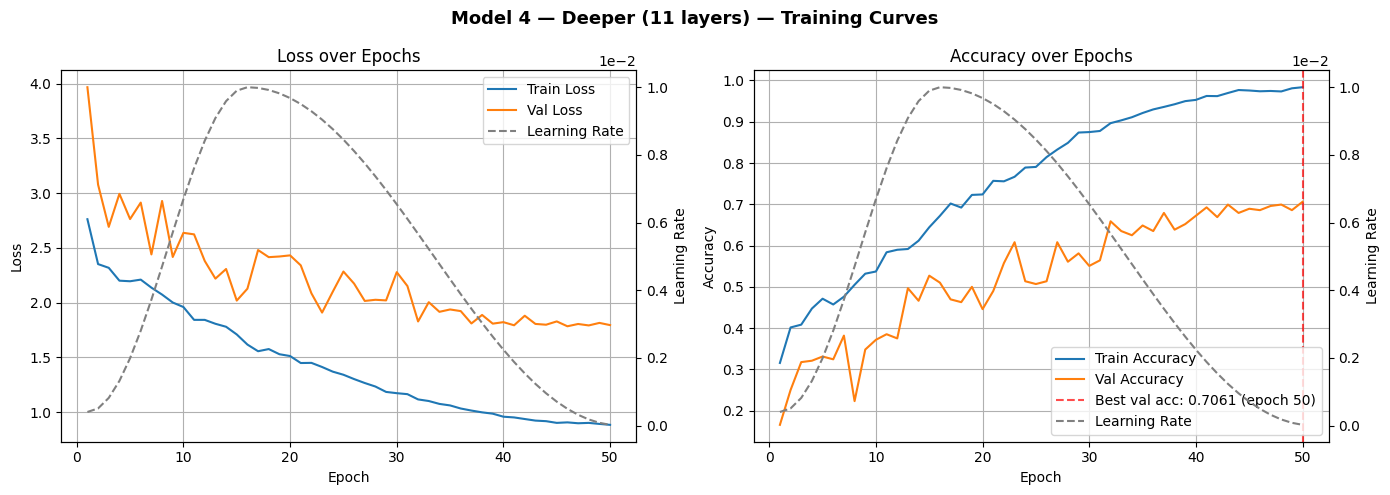

In [29]:
# Evaluate Model
test_acc = evaluate(model=model_11, test_dl=test_dl, n_classes=N_CLASSES, train_losses=train_losses, val_losses=val_losses, train_accuracies=train_accuracies, val_accuracies=val_accuracies, model_name="Model 4 — Deeper (11 layers)")

**Result:** despite more parameters (~7.6 M), test accuracy *drops* to 0.7517. Deeper networks are harder to optimize, particularly with limited data, because gradients can vanish across many sequential layers.

The regression raises a **diagnostic question** with two competing hypotheses:

1. **Hypothesis A, Overfitting:** the network has too much capacity for the dataset size and memorizes training examples instead of generalizing
2. **Hypothesis B, Optimization difficulty:** gradients struggle to propagate through many sequential layers (vanishing gradient problem)

The next two experiments test these hypotheses in order.

In [30]:
del(model_11)  # free up memory

### Model 5, Testing Hypothesis A: Overfitting (Dropout)

**Hypothesis A** predicts that reducing the network's ability to memorize should help. **Dropout** is a standard regularization technique that randomly disables a fraction of neurons at each training step, forcing the network to learn more distributed and robust representations.

If dropout improves validation accuracy → overfitting is the main problem.
If dropout makes things worse → the problem lies elsewhere (Hypothesis B).

In [31]:
class ClassifierDropout(nn.Module):          # subclassing nn.Module
    def __init__(self, n_classes, dropout=0.15):
        super().__init__()

        #Repetition of stages taking inspiration from VGG.
        #Adding BatchNorm for faster convergence and averaging out spatial dimensions.
        self.features_extractor = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True)
        )

        # Global Average Pooling classifier averaging out Spatial Dimensions taking inspiration from Inception V1
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),     # Averages spatial dimensions
            nn.Flatten(),
            nn.Linear(512, n_classes)         # Outputs the class scores
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features_extractor(x)    # Pass input through the feature extractor
        x = self.classifier(x)
        return x

The peak learning rate is also reduced based on Model 4's loss trajectory, which showed signs of instability at higher LR values.

In [32]:
N_CLASSES = train_ds.get_num_classes()
model_dropout = ClassifierDropout(
    N_CLASSES
).to(device)


# using pytorch OneCycleLR
EPOCHS = 50
PATIENCE = None                                                                             # no early stopping
OPTIMIZER = torch.optim.Adam(model_dropout.parameters(), lr=0.001)                          # LOWERING starting lr, seeing previous loss graphs
SCHEDULER = OneCycleLR(OPTIMIZER, max_lr=0.001, total_steps=EPOCHS * len(train_dl), final_div_factor=10000)   # from 1e-3 to 1e-7
CRITERION = nn.CrossEntropyLoss(label_smoothing = 0.1)                                      # label smoothing -> correct will be 0.9

results = fit_cached(
    model_dropout, tag="model5_dropout",
    train_dl=train_dl,
    val_dl=val_dl,
    criterion=CRITERION,  # loss
    opt=OPTIMIZER,
    scheduler=SCHEDULER,
    epochs=EPOCHS,
    patience=PATIENCE,
    verbose=True          # print progress
)

best_val_acc, best_weights, best_epoch, train_losses, val_losses, train_accuracies, val_accuracies = results

[cache] loaded 'model5_dropout' from weights/model5_dropout.pth — skipping training (best val acc 0.6318)



Test Set Accuracy [Model 5 — Dropout]: 0.7155


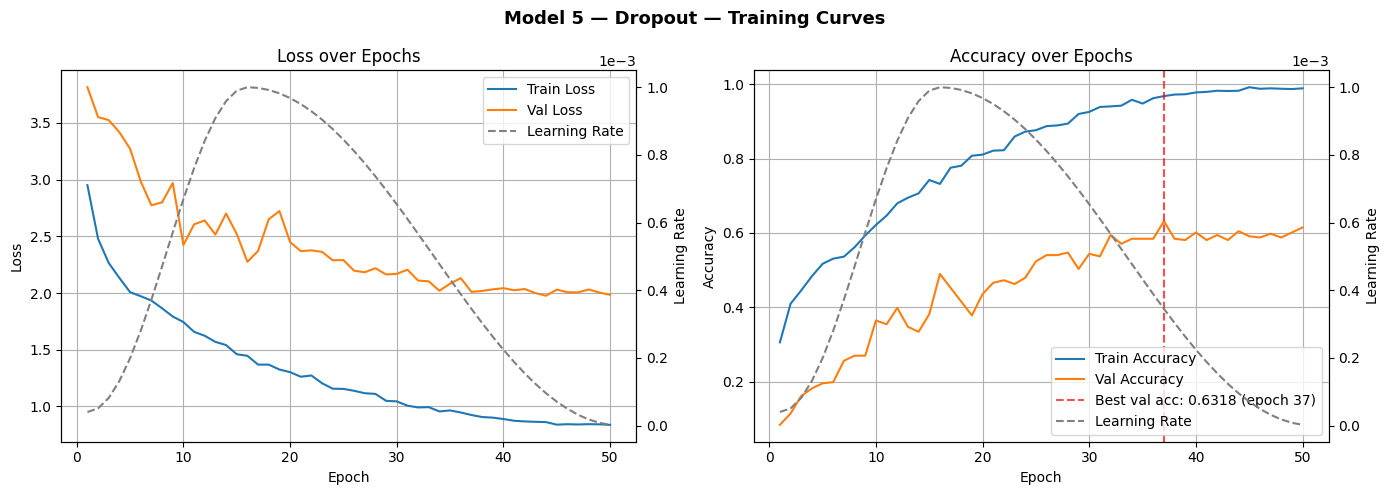

In [33]:
# Evaluate Model
test_acc = evaluate(model=model_dropout, test_dl=test_dl, n_classes=N_CLASSES, train_losses=train_losses, val_losses=val_losses, train_accuracies=train_accuracies, val_accuracies=val_accuracies, model_name="Model 5 — Dropout")

**Result**: dropout reduces performance further, best validation accuracy 0.6318. **Hypothesis A is rejected**.

On a dataset of this size, the noise introduced by randomly dropping activations impairs convergence more than it helps generalization. The network does not have enough training signal to benefit from this level of regularization.

This shifts the diagnosis entirely to **Hypothesis B: optimization difficulty**. The problem is not that the network is too powerful, it is that deep sequential architectures make it structurally hard for gradients to flow back to early layers. The solution is not regularization, but a structural change to gradient flow.

In [34]:
del(model_dropout)  # free up memory

### Model 6, Testing Hypothesis B: Gradient Flow (Residual Connections)

**Hypothesis B** is confirmed by Model 5's failure: the regression in deeper models is an optimization problem, not a capacity problem. **Residual (skip) connections** are the targeted architectural fix.

A skip connection adds a direct shortcut from the input to the output of each block, bypassing the intermediate layers. This creates a **gradient highway**: during backpropagation, gradients can flow directly through the shortcut without being attenuated by multiple non-linearities. Deep networks with skip connections are significantly easier to train than equally deep networks without them.

**Implementation detail.** The channel count changes at every block (3 → 64 → 128 → 256 → 512), so the identity shortcut cannot be added directly — its dimensions don't match the block output. Each block therefore uses a **1×1 convolution "projection shortcut"** on the skip path to project the input to the block's output channels (the projection-shortcut option of He et al., 2015). Within a block the order is `Conv → BN → ReLU → Conv → BN`; the projected shortcut is then added, and a final **ReLU is applied after the addition** — the canonical ResNet block ordering. The peak learning rate stays at the lower `1e-3` that the deeper Models 4–5 showed was necessary.

**All design choices carried forward into Model 6:**

| Component | Validated by | Rationale |
|---|---|---|
| 3-stage progressive structure | Models 1 → 2 → 3 | Each added stage improved val accuracy |
| Batch normalization | Baseline (all models) | Stabilizes layer activations; ablation will confirm |
| Global average pooling head | Baseline (all models) | Avoids parameter explosion before classifier |
| OneCycleLR scheduler | Baseline (all models) | Warmup + decay; ablation will confirm |
| No dropout | Model 5 (rejected) | Hurts convergence on small datasets |
| **Residual connections** | **New addition** | **Fixes gradient flow, targets the root cause of Model 4's regression** |

In [35]:
# defining residual block
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=strides)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # match dimension of skip connections to add it
        self.conv_skip = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=strides)

    def forward(self, x):
        residual = x
        # First convolution block,
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # Second convolution block
        out = self.conv2(out)
        out = self.bn2(out)

        # adjust dimensions of skip connection
        residual = self.conv_skip(residual)

        # Add skip connection
        out += residual
        out = self.relu(out)
        return out

In [36]:
# constructing net using residual block
class ResidualNN(nn.Module):
    def __init__(self, n_classes, dropout=0.15):
        super().__init__()

        # Feature extractor with residual blocks
        self.features_extractor = nn.Sequential(
            # Block 1
            ResidualBlock(3, 64),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            ResidualBlock(64, 128),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            ResidualBlock(128, 256),
            ResidualBlock(256, 256),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4
            ResidualBlock(256, 512),
            ResidualBlock(512, 512)
        )

        # Global Average Pooling classifier
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),     # Averages spatial dimensions
            nn.Flatten(),
            nn.Linear(512, n_classes)         # Outputs the class scores
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features_extractor(x)        # Pass input through the feature extractor
        x = self.classifier(x)                # Classifier stage
        return x

In [37]:
N_CLASSES = train_ds.get_num_classes()
model_res = ResidualNN(
    N_CLASSES
).to(device)

total_params = sum(p.numel() for p in model_res.parameters() if p.requires_grad)
print(f"Total trainable PARAMETERS of the model: {total_params}")
print()


# using pytorch OneCycleLR
EPOCHS = 50
PATIENCE = None                                                                               # no early stopping
OPTIMIZER = torch.optim.Adam(model_res.parameters(), lr=0.001)                                # LOWERING starting lr, seeing previous loss graphs
SCHEDULER = OneCycleLR(OPTIMIZER, max_lr=0.001, total_steps=EPOCHS * len(train_dl), final_div_factor=10000)     # from 1e-3 to 1e-7
CRITERION = nn.CrossEntropyLoss(label_smoothing = 0.1)                                        # label smoothing -> correct will be 0.9

results = fit_cached(
    model_res, tag="model6_residual",
    train_dl=train_dl,
    val_dl=val_dl,
    criterion=CRITERION,  # loss
    opt=OPTIMIZER,
    scheduler=SCHEDULER,
    epochs=EPOCHS,
    patience=PATIENCE,
    verbose=True          # print progress
)

best_val_acc, best_weights, best_epoch, train_losses, val_losses, train_accuracies, val_accuracies = results

Total trainable PARAMETERS of the model: 11115755

[cache] loaded 'model6_residual' from weights/model6_residual.pth — skipping training (best val acc 0.7331)



Test Set Accuracy [Model 6 — Residual]: 0.8056


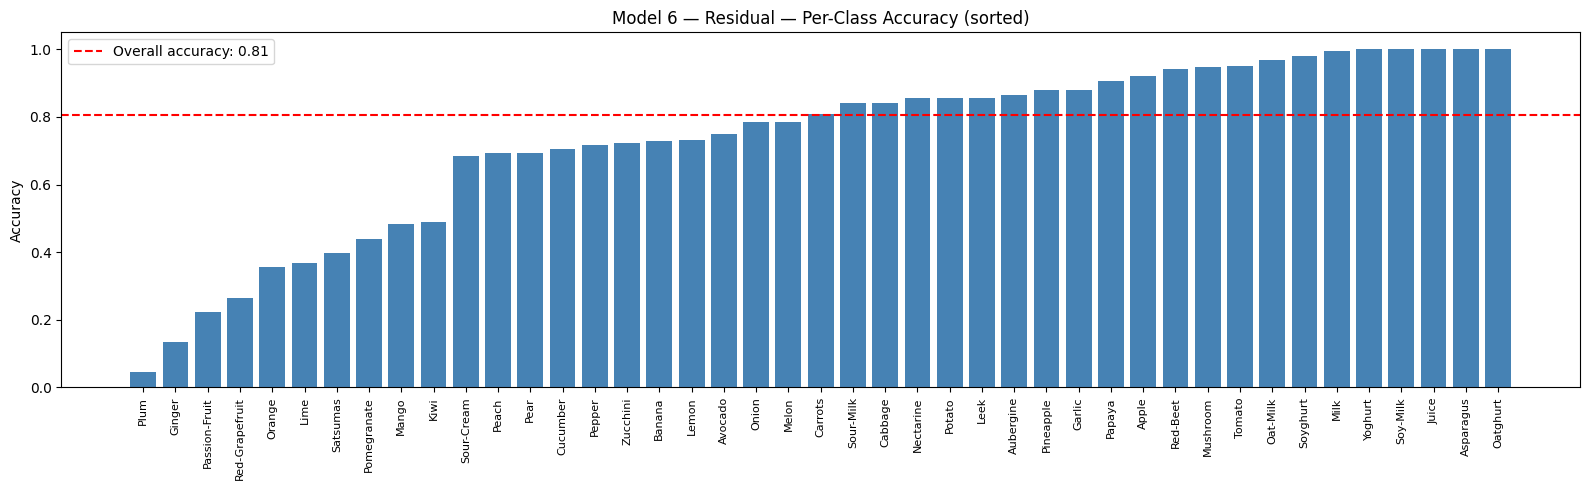

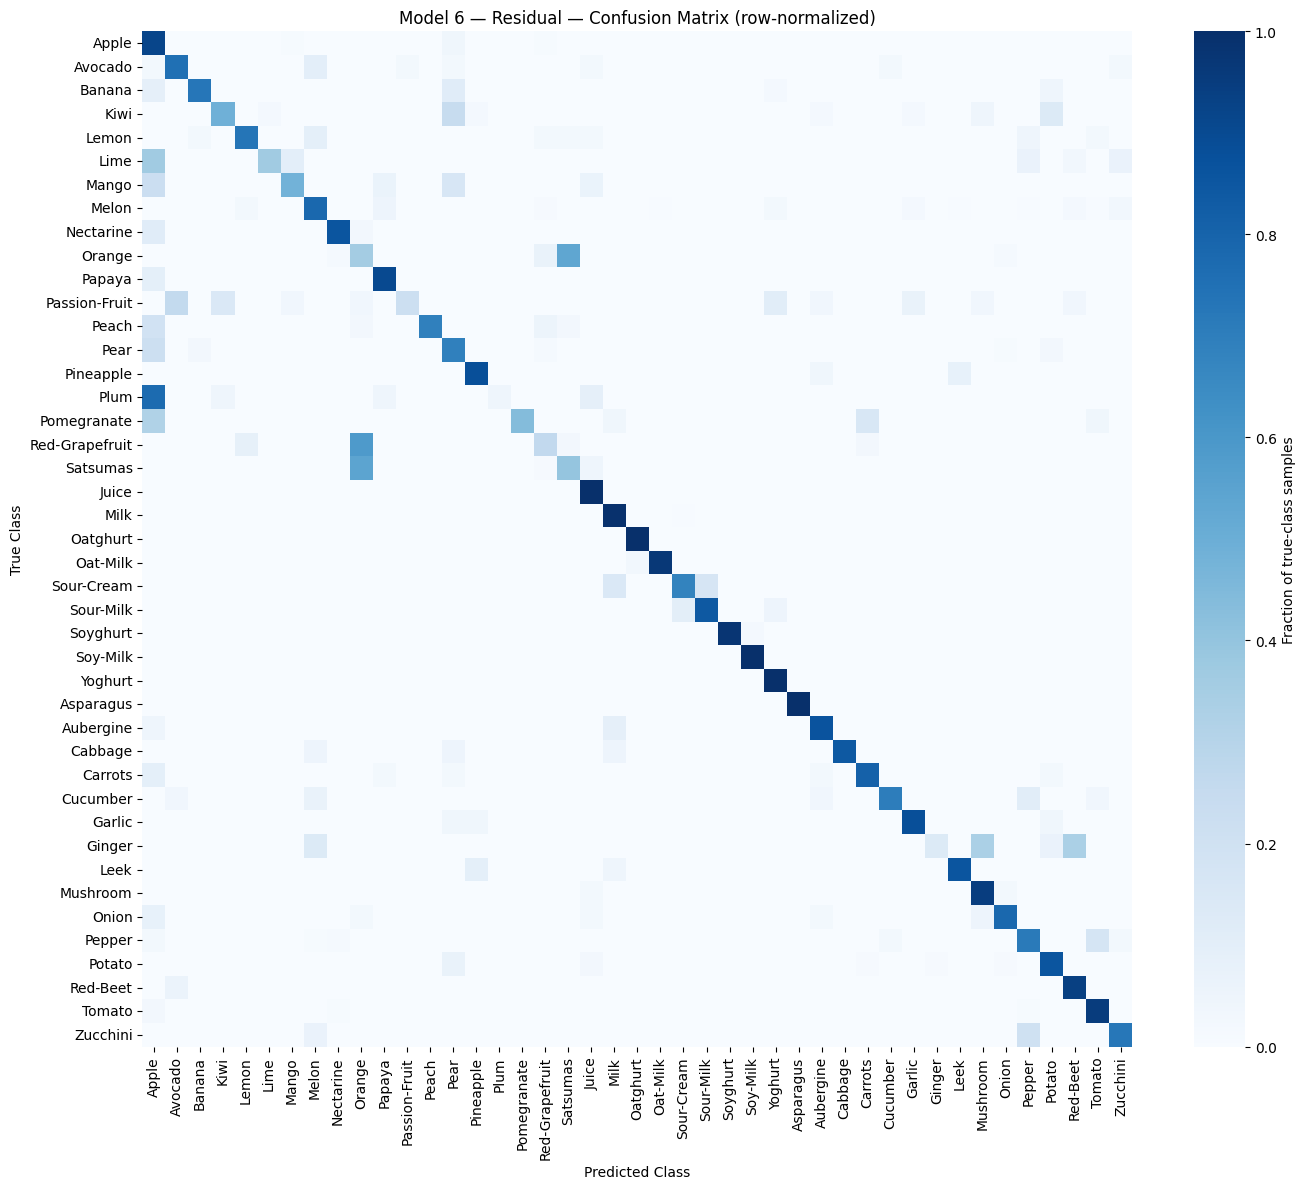

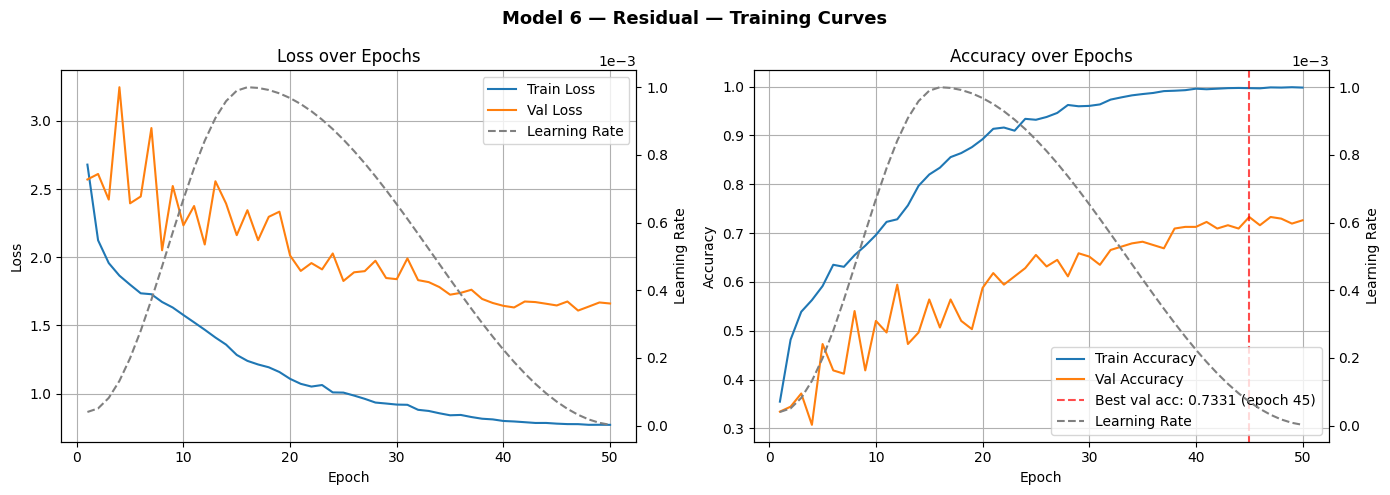

In [38]:
# Evaluate Model
test_acc = evaluate(model=model_res, test_dl=test_dl, n_classes=N_CLASSES, train_losses=train_losses, val_losses=val_losses, train_accuracies=train_accuracies, val_accuracies=val_accuracies, model_name="Model 6 — Residual", plot_confusion_matrix=True, class_names=CLASS_NAMES)

**Result**: skip connections restore and exceed the accuracy of the smaller Model 3, best validation accuracy **0.7331** (test: 0.8072) at 11 M parameters. The combination of increased depth and residual connections proves the most effective design so far.

In [39]:
del(model_res)  # free up memory

---

## Ablation Study

The design study above validated architectural choices by *adding* components and measuring improvements. However, **batch normalization** and the **OneCycleLR scheduler** were present in every model from the start, they were never tested in isolation.

The ablation study fills this gap. Each component is *removed* from Model 6 independently, and the performance drop is measured. This formally confirms that both are genuine contributors to the final result, not accidental additions that happen to be present.

### Removing Batch Normalization

Batch normalization normalizes the distribution of activations at each layer, reducing internal covariate shift. This makes training more stable and allows higher learning rates without divergence. Removing it tests whether Model 6's performance genuinely depends on this stabilization.

In [40]:
# defining residual block
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=strides)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # match dimension of skip connections to add it
        self.conv_skip = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=strides)

    def forward(self, x):
        residual = x
        # First convolution block, without batch norm
        out = self.conv1(x)
        #out = self.bn1(out)
        out = self.relu(out)

        # Second convolution block, without batch norm
        out = self.conv2(out)
        #out = self.bn2(out)

        # adjust dimensions of skip connection
        residual = self.conv_skip(residual)

        # Add skip connection
        out += residual
        out = self.relu(out)
        return out

In [41]:
N_CLASSES = train_ds.get_num_classes()
model_res_no_bn = ResidualNN(
    N_CLASSES
).to(device)

total_params = sum(p.numel() for p in model_res_no_bn.parameters() if p.requires_grad)
print(f"Total trainable PARAMETERS of the model: {total_params}")
print()


# using pytorch OneCycleLR
EPOCHS = 50
PATIENCE = None                                                                               # no early stopping
OPTIMIZER = torch.optim.Adam(model_res_no_bn.parameters(), lr=0.001)
SCHEDULER = OneCycleLR(OPTIMIZER, max_lr=0.001, total_steps=EPOCHS * len(train_dl), final_div_factor=10000)     # from 1e-3 to 1e-7
CRITERION = nn.CrossEntropyLoss(label_smoothing = 0.1)                                        # label smoothing -> correct will be 0.9

results = fit_cached(
    model_res_no_bn, tag="ablation_no_bn",
    train_dl=train_dl,
    val_dl=val_dl,
    criterion=CRITERION,  # loss
    opt=OPTIMIZER,
    scheduler=SCHEDULER,
    epochs=EPOCHS,
    patience=PATIENCE,
    verbose=True          # print progress
)

best_val_acc, best_weights, best_epoch, train_losses, val_losses, train_accuracies, val_accuracies = results

Total trainable PARAMETERS of the model: 11115755

[cache] loaded 'ablation_no_bn' from weights/ablation_no_bn.pth — skipping training (best val acc 0.6520)



Test Set Accuracy [Ablation — No BatchNorm]: 0.7155


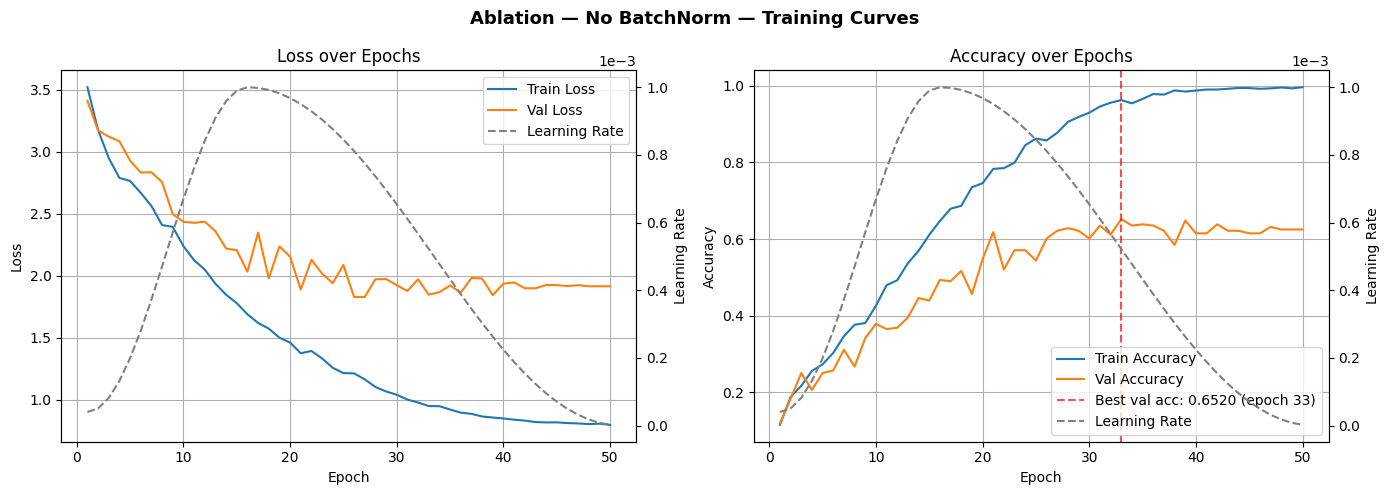

In [42]:
# Evaluate Model
test_acc = evaluate(model=model_res_no_bn, test_dl=test_dl, n_classes=N_CLASSES, train_losses=train_losses, val_losses=val_losses, train_accuracies=train_accuracies, val_accuracies=val_accuracies, model_name="Ablation — No BatchNorm")

**Result**: removing batch normalization *drops* validation accuracy to 0.6520. Batch norm is critical for stabilizing training in deeper networks, without it, layer activations shift unpredictably, slowing and destabilizing convergence.

In [43]:
del(model_res_no_bn)  # free up memory

### Removing the Learning Rate Scheduler

The OneCycleLR scheduler is replaced with a fixed learning rate. The full architecture (Model 6, with skip connections and batch normalization) is kept identical. This isolates the scheduler's contribution to convergence quality from all other factors.

Total trainable PARAMETERS of the model: 11115755

[cache] loaded 'ablation_no_sched' from weights/ablation_no_sched.pth — skipping training (best val acc 0.6453)

Test Set Accuracy [Ablation — No LR Scheduler]: 0.6853


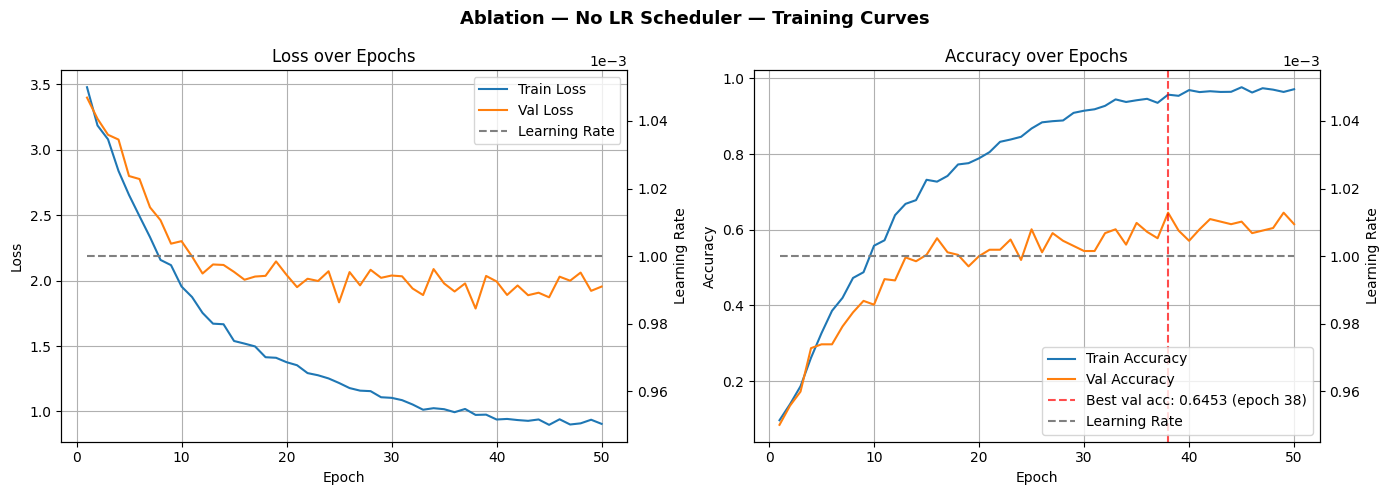

In [44]:
N_CLASSES = train_ds.get_num_classes()
model_res_no_sched = ResidualNN(
    N_CLASSES
).to(device)

total_params = sum(p.numel() for p in model_res_no_sched.parameters() if p.requires_grad)
print(f"Total trainable PARAMETERS of the model: {total_params}")
print()


# REMOVING lr scheduler to show difference in convergence
EPOCHS = 50
PATIENCE = None                                                                               # no early stopping
OPTIMIZER = torch.optim.Adam(model_res_no_sched.parameters(), lr=0.001)
SCHEDULER = None
CRITERION = nn.CrossEntropyLoss(label_smoothing = 0.1)                                        # label smoothing -> correct will be 0.9

results = fit_cached(
    model_res_no_sched, tag="ablation_no_sched",
    train_dl=train_dl,
    val_dl=val_dl,
    criterion=CRITERION,  # loss
    opt=OPTIMIZER,
    scheduler=SCHEDULER,
    epochs=EPOCHS,
    patience=PATIENCE,
    verbose=True          # print progress
)

best_val_acc, best_weights, best_epoch, train_losses, val_losses, train_accuracies, val_accuracies = results
# Evaluate Model
test_acc = evaluate(model=model_res_no_sched, test_dl=test_dl, n_classes=N_CLASSES, train_losses=train_losses, val_losses=val_losses, train_accuracies=train_accuracies, val_accuracies=val_accuracies, model_name="Ablation — No LR Scheduler")

**Result**: removing the scheduler drops validation accuracy to 0.6453. The OneCycleLR warmup and decay phases play a clear role in convergence: the initial warmup avoids poor early local optima, and the final decay allows the optimizer to descend into sharper, lower-loss minima.

In [45]:
del(model_res_no_sched)  # free up memory

---

## Part 1, Results Summary

The table below is **generated from the recorded `MODEL_RESULTS`**. The **Change** and **Decision** columns are the study's static annotations; **Params**, **Best Val Acc**, and **Test Acc** come straight from the experiments.

In [46]:
from IPython.display import display

# Static study annotations; the accuracy numbers are pulled live from MODEL_RESULTS.
# (Params are architecture-fixed: padding does not change weight counts, and the GAP head
#  makes the classifier size independent of spatial resolution.)
PART1_TABLE = [
    ("Model 1, Single-Stage",       "Model 1 — Single-Stage",       "Baseline",                    "41 k",   "Starting point"),
    ("Model 2, Two-Stage",          "Model 2 — Two-Stage",          "+1 conv stage",               "260 k",  "Depth helps, keep"),
    ("Model 3, Three-Stage",        "Model 3 — Three-Stage",        "+1 conv stage",               "1.75 M", "Depth helps, keep"),
    ("Model 4, Deeper (11 layers)", "Model 4 — Deeper (11 layers)", "More layers per stage",       "7.6 M",  "Regression, diagnose"),
    ("Model 5, Dropout",            "Model 5 — Dropout",            "+Dropout (test Hyp. A)",      "7.6 M",  "Overfitting hyp. rejected"),
    ("Model 6, Residual",           "Model 6 — Residual",           "+Skip connections (Hyp. B)",  "11 M",   "Best model, Hyp. B confirmed"),
    ("Ablation: No BatchNorm",      "Ablation — No BatchNorm",      "-BatchNorm",                  "11 M",   "BatchNorm confirmed necessary"),
    ("Ablation: No LR Scheduler",   "Ablation — No LR Scheduler",   "Fixed LR",                    "11 M",   "Scheduler confirmed necessary"),
]

def _fmt(key, field):
    r = MODEL_RESULTS.get(key)
    return f"{r[field]:.4f}" if r else "—"

summary_df = pd.DataFrame(
    [{"Change vs previous": ch, "Params": pa,
      "Best Val Acc": _fmt(key, "best_val_acc"), "Test Acc": _fmt(key, "test_acc"),
      "Decision": de}
     for name, key, ch, pa, de in PART1_TABLE],
    index=[name for name, *_ in PART1_TABLE],
)
display(summary_df)

# Per-component impact, computed live (percentage points of validation accuracy)
def _delta(better, worse):
    if better in MODEL_RESULTS and worse in MODEL_RESULTS:
        return f"{100 * (MODEL_RESULTS[better]['best_val_acc'] - MODEL_RESULTS[worse]['best_val_acc']):+.1f} pp"
    return "—"

ablation_df = pd.DataFrame([
    {"Component": "Depth (3 stages)",     "Comparison": "Model 6 vs Model 1", "Delta Val Acc": _delta("Model 6 — Residual", "Model 1 — Single-Stage")},
    {"Component": "Residual connections", "Comparison": "Model 6 vs Model 4", "Delta Val Acc": _delta("Model 6 — Residual", "Model 4 — Deeper (11 layers)")},
    {"Component": "Batch normalization",  "Comparison": "Model 6 vs no-BN",   "Delta Val Acc": _delta("Model 6 — Residual", "Ablation — No BatchNorm")},
    {"Component": "OneCycleLR scheduler", "Comparison": "Model 6 vs no-sched","Delta Val Acc": _delta("Model 6 — Residual", "Ablation — No LR Scheduler")},
    {"Component": "Dropout (added)",      "Comparison": "Model 5 vs Model 4", "Delta Val Acc": _delta("Model 5 — Dropout", "Model 4 — Deeper (11 layers)")},
])
print("Per-component impact (positive = the component helps validation accuracy):")
display(ablation_df)

_main = [key for _, key, *_ in PART1_TABLE[:6] if key in MODEL_RESULTS]
if _main:
    best = max(_main, key=lambda k: MODEL_RESULTS[k]["best_val_acc"])
    print(f"\nBest Part 1 model: {best} — "
          f"val {MODEL_RESULTS[best]['best_val_acc']:.4f}, test {MODEL_RESULTS[best]['test_acc']:.4f}")

,Change vs previous,Params,Best Val Acc,Test Acc,Decision
"Model 1, Single-Stage",Baseline,41 k,0.5811,0.5835,Starting point
"Model 2, Two-Stage",+1 conv stage,260 k,0.6419,0.7505,"Depth helps, keep"
"Model 3, Three-Stage",+1 conv stage,1.75 M,0.6689,0.7541,"Depth helps, keep"
"Model 4, Deeper (11 layers)",More layers per stage,7.6 M,0.7061,0.7517,"Regression, diagnose"
"Model 5, Dropout",+Dropout (test Hyp. A),7.6 M,0.6318,0.7155,Overfitting hyp. rejected
"Model 6, Residual",+Skip connections (Hyp. B),11 M,0.7331,0.8056,"Best model, Hyp. B confirmed"
Ablation: No BatchNorm,-BatchNorm,11 M,0.6520,0.7155,BatchNorm confirmed necessary
Ablation: No LR Scheduler,Fixed LR,11 M,0.6453,0.6853,Scheduler confirmed necessary


Per-component impact (positive = the component helps validation accuracy):


,Component,Comparison,Delta Val Acc
0,Depth (3 stages),Model 6 vs Model 1,+15.2 pp
1,Residual connections,Model 6 vs Model 4,+2.7 pp
2,Batch normalization,Model 6 vs no-BN,+8.1 pp
3,OneCycleLR scheduler,Model 6 vs no-sched,+8.8 pp
4,Dropout (added),Model 5 vs Model 4,-7.4 pp



Best Part 1 model: Model 6 — Residual — val 0.7331, test 0.8056


### Best Model, Model 6 Architecture Summary

Model 6 is the direct cumulative product of every validated decision in this study. Each component earned its place through an experiment; the **per-component impact is quantified in the ablation table above**.

| Component | Contribution |
|---|---|
| 3-stage progressive depth | Core accuracy driver (Models 1→2→3) |
| Residual skip connections | Fixes gradient flow in the deep network |
| Batch normalization | Stabilizes activations; enables depth |
| OneCycleLR scheduler | Warmup + decay for reliable convergence |
| Global average pooling head | Keeps parameters manageable |
| No dropout | Dropout rejected as harmful (Model 5) |

**Best Part 1 result:** see the generated summary above (Model 6).

The study shows that on a moderately sized dataset like GroceryStoreDataset, **architecture choice matters more than raw parameter count**: Model 3 (1.75 M) outperforms Model 4 (7.6 M) because blindly adding depth causes optimization to fail. The real lever is making depth *trainable*, which residual connections achieve with minimal overhead.

The diagnostic path through Models 4 and 5 was essential: without explicitly testing and rejecting the overfitting hypothesis (Model 5), the correct fix (skip connections in Model 6) would have lacked a clear justification.

The ablation table above quantifies the cost of removing each baseline component: both batch normalization and the LR scheduler are non-negotiable for this task.

### Visual Model Comparison

The table above lists the final numbers; overlaying the six models' validation-accuracy trajectories makes the design progression visible at a glance — how added depth (Models 2–3) lifts the curve, how the deeper *plain* network (Model 4) stalls, and how residual connections (Model 6) recover and surpass it. The curves are collected automatically as each model is evaluated (`MODEL_RESULTS`).

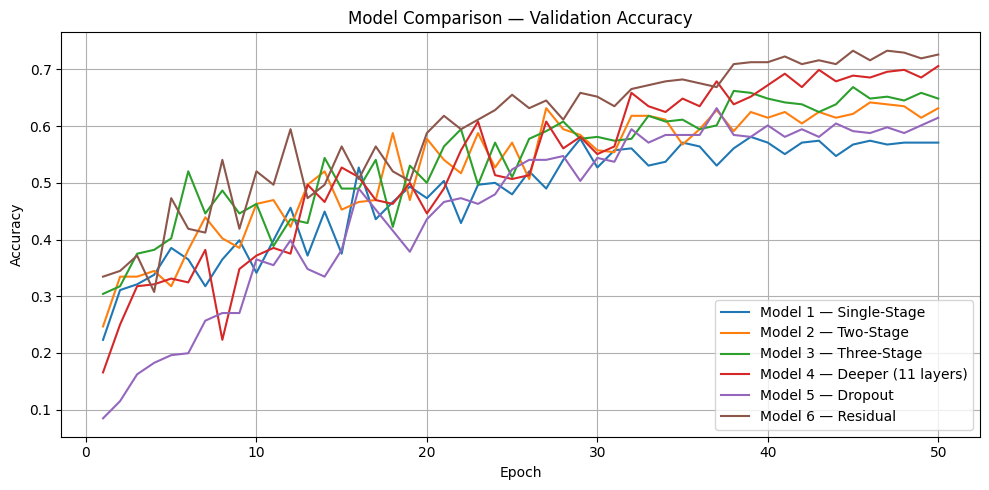

In [47]:
# Overlay the validation-accuracy curves of the six architecture-study models.
# (MODEL_RESULTS is populated by evaluate(); run the model cells above first.)
main_models = [
    "Model 1 — Single-Stage",
    "Model 2 — Two-Stage",
    "Model 3 — Three-Stage",
    "Model 4 — Deeper (11 layers)",
    "Model 5 — Dropout",
    "Model 6 — Residual",
]
compare_models([{"name": k, **MODEL_RESULTS[k]} for k in main_models if k in MODEL_RESULTS],
               metric="val_accuracy")

---

# Part 2: Fine-Tuning Pretrained ResNet-18

A ResNet-18 pretrained on ImageNet-1K (V1) is adapted to the GroceryStoreDataset. Transfer learning leverages the rich visual features already learned from ImageNet, which overlap substantially with grocery product imagery.

The fine-tuning is split into two steps: first only the classification head is trained; then the entire network is unfrozen for a refined second pass.

In [48]:
import torchvision.models as models
from torchvision.models import ResNet18_Weights

# import ResNet-18 pretrained on ImageNet-1K (V1)
resnet18 = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# freezing all layers and adding a new classifier to the NN
for param in resnet18.parameters():
    param.requires_grad = False

# replacing last layer and making sure it's unfrozen
N_CLASSES = train_ds.get_num_classes()
N_FTRS = resnet18.fc.in_features
resnet18.fc = nn.Linear(N_FTRS, N_CLASSES)
for param in resnet18.fc.parameters():
    param.requires_grad = True


## Step 1, Head-Only Fine-Tuning

All convolutional layers are frozen. Only the newly added classification head (replacing the original ImageNet FC layer) is trained, using the same hyperparameters as the best custom model.

In [49]:
N_CLASSES = train_ds.get_num_classes()
resnet18.to(device)

# using pytorch OneCycleLR
EPOCHS = 50
PATIENCE = None                                                                               # no early stopping
OPTIMIZER = torch.optim.Adam(resnet18.parameters(), lr=0.001)                                 # LOWERING starting lr, seeing previois loss graphs
SCHEDULER = OneCycleLR(OPTIMIZER, max_lr=0.001, total_steps=EPOCHS * len(train_dl), final_div_factor=10000)     # from 1e-3 to 1e-7
CRITERION = nn.CrossEntropyLoss(label_smoothing = 0.1)                                        # label smoothing -> correct will be 0.9

results = fit_cached(
    resnet18, tag="resnet18_head",
    train_dl=train_dl,
    val_dl=val_dl,
    criterion=CRITERION,  # loss
    opt=OPTIMIZER,
    scheduler=SCHEDULER,
    epochs=EPOCHS,
    patience=PATIENCE,
    verbose=True          # print progress
)


best_val_acc, best_weights, best_epoch, train_losses, val_losses, train_accuracies, val_accuracies = results

[cache] loaded 'resnet18_head' from weights/resnet18_head.pth — skipping training (best val acc 0.8209)



Test Set Accuracy [ResNet-18 — Head Only]: 0.8447


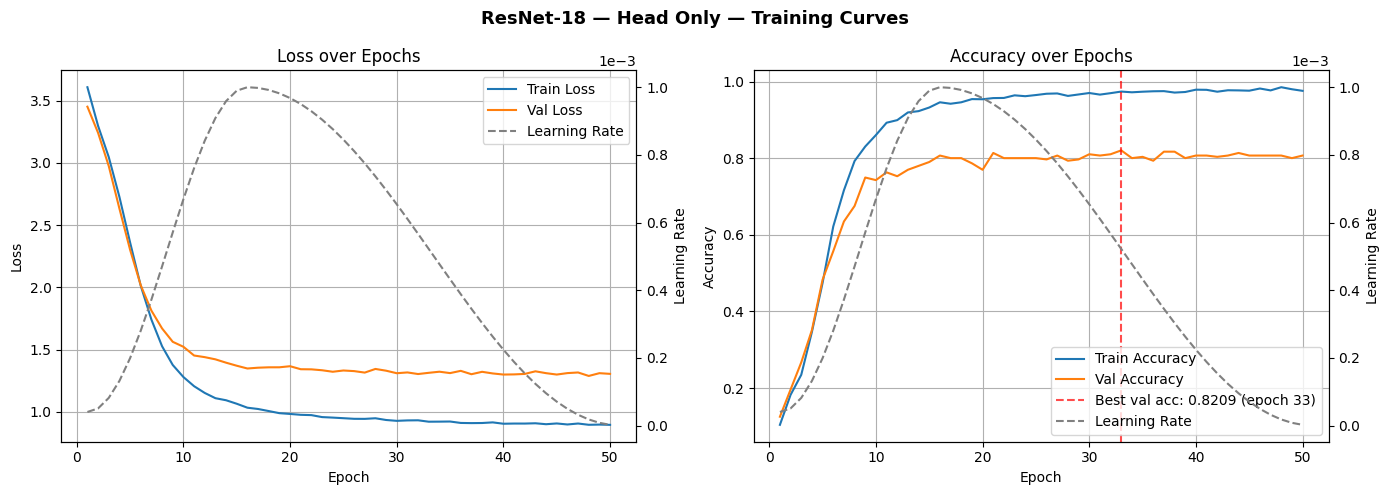

In [50]:
# Evaluate Model
test_acc = evaluate(model=resnet18, test_dl=test_dl, n_classes=N_CLASSES, train_losses=train_losses, val_losses=val_losses, train_accuracies=train_accuracies, val_accuracies=val_accuracies, model_name="ResNet-18 — Head Only")

**Result**: with only the head trained, the model already reaches **0.8209** validation accuracy, well above the custom CNN. The pretrained features generalize strongly to grocery products. However, the final convolutional layers are still tuned toward ImageNet categories, motivating a full-network fine-tuning pass.

## Step 2, Full Fine-Tuning with Layer-wise Learning Rate

All layers are unfrozen. A **discriminative (sliced) learning rate** is applied: earlier layers, which hold general transferable features, receive a lower LR; later layers, which encode task-specific features, receive a higher LR. This approach is inspired by the Fast.ai library's transfer-learning implementation.

Concretely the parameters are split into three groups: the new **`fc` head** gets the highest rate (`1e-4` — it is randomly initialised and must adapt the most), **`layer4`** — the last residual stage, encoding the most abstract, task-specific features — gets a smaller rate (`1e-5`), and **all earlier layers** get an essentially negligible rate (`1e-12`), keeping their general ImageNet features almost frozen. The intent is the ordering **head > deep backbone > shallow backbone**.

*Note: OneCycleLR is currently constructed with a single scalar `max_lr`, so it drives every parameter group with the same schedule shape and the three configured rates are not fully preserved during training. To realise the discriminative-LR intent exactly, pass a list of per-group `max_lr` values to `OneCycleLR`.*

In [51]:
# Architecture and parameter counts of the ResNet-18 to be fine-tuned
print(resnet18)

total_params = sum(p.numel() for p in resnet18.parameters())
trainable_params = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [52]:
resnet18.load_state_dict(torch.load(os.path.join(WEIGHTS_DIR, "resnet18_head.pth"), map_location=device))

# unfreezing layers
for param in resnet18.parameters():
    param.requires_grad = True

# setting a sliced learning rate for the model -> last layers will train faster
OPTIMIZER = torch.optim.Adam([
    {'params': resnet18.layer4.parameters(), 'lr': 1e-5},   # Layer 4 targets the last block responsible of higher level and more abstract features
    {'params': resnet18.fc.parameters(), 'lr': 1e-4},       # Highest learning rate for the classifier layer
], lr=1e-12)                                                # Default lower learning rate for the rest


# using pytorch OneCycleLR
EPOCHS = 30
PATIENCE = None                                                                               # no early stopping
SCHEDULER = OneCycleLR(OPTIMIZER, max_lr=0.0001, total_steps=EPOCHS * len(train_dl), final_div_factor=10000)     # from 1e-3 to 1e-7
CRITERION = nn.CrossEntropyLoss(label_smoothing = 0.1)                                        # label smoothing -> correct will be 0.9

results = fit_cached(
    resnet18, tag="resnet18_full",
    train_dl=train_dl,
    val_dl=val_dl,
    criterion=CRITERION,  # loss
    opt=OPTIMIZER,
    scheduler=SCHEDULER,
    epochs=EPOCHS,
    patience=PATIENCE,
    verbose=True          # print progress
)

best_val_acc, best_weights, best_epoch, train_losses, val_losses, train_accuracies, val_accuracies = results

[cache] loaded 'resnet18_full' from weights/resnet18_full.pth — skipping training (best val acc 0.8919)



Test Set Accuracy [ResNet-18 — Full Fine-Tune]: 0.8970


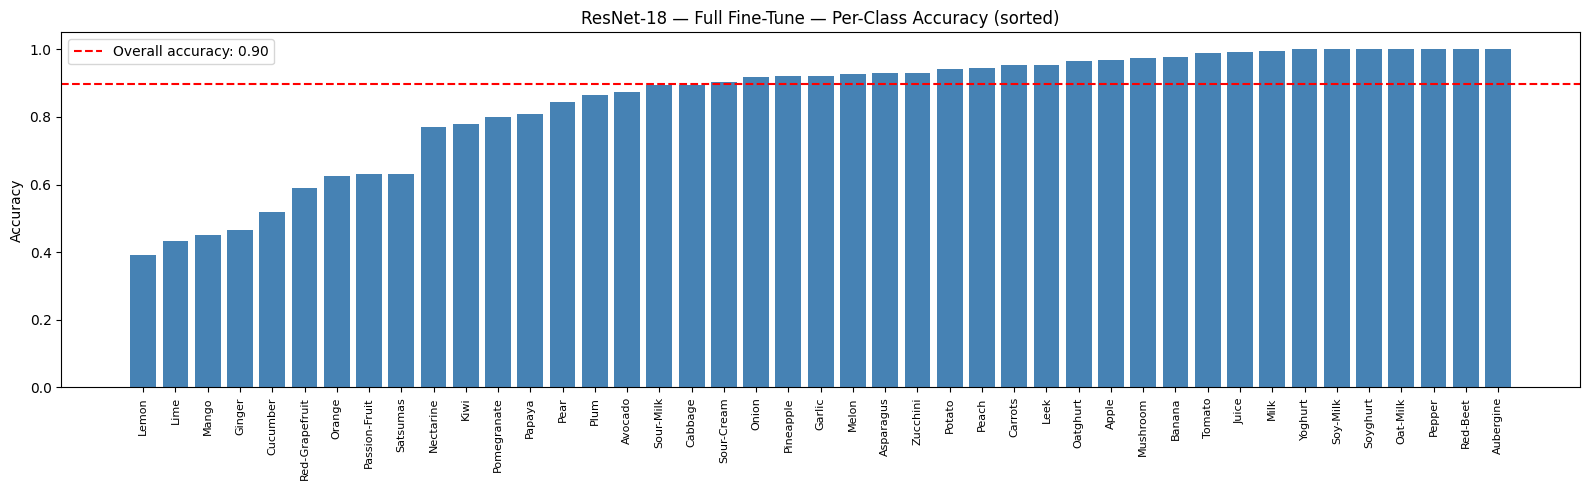

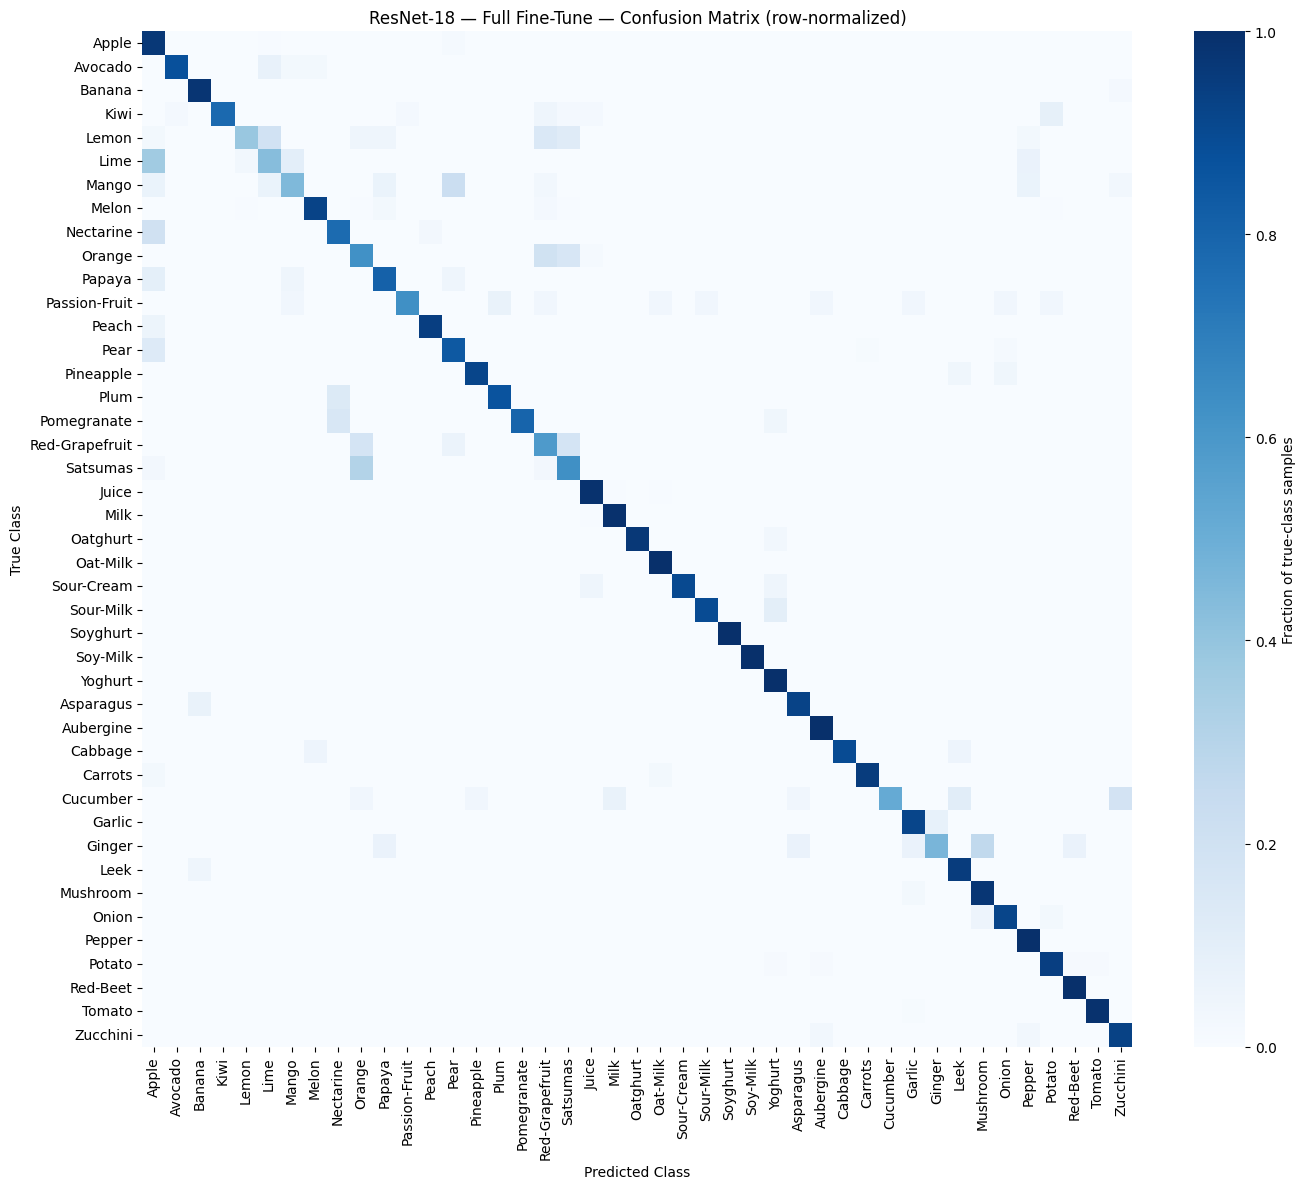

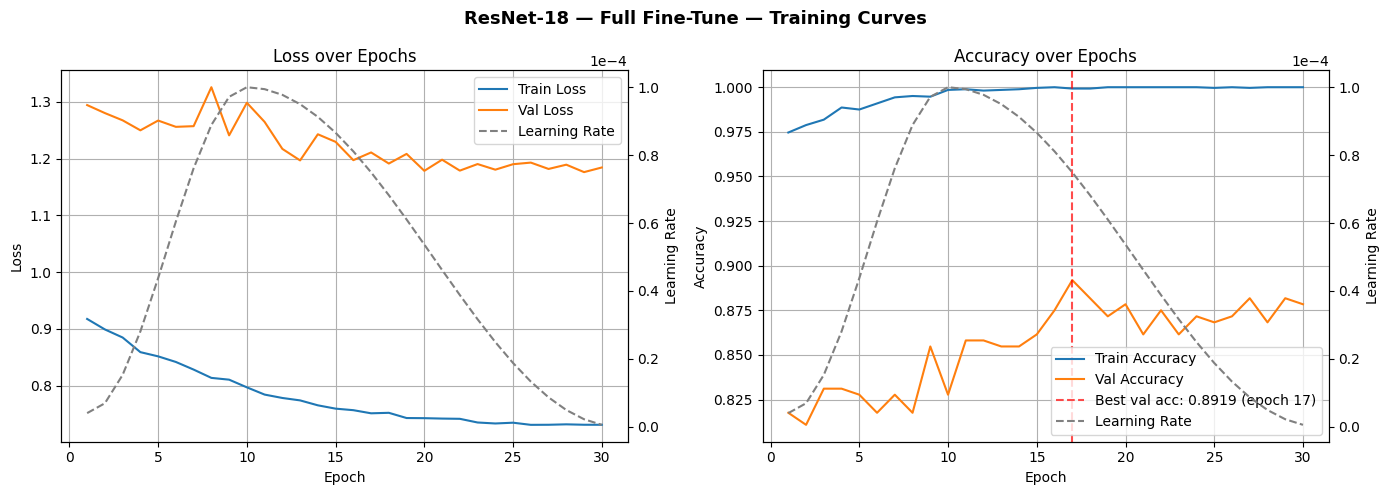

In [53]:
# Evaluate Model
test_acc = evaluate(model=resnet18, test_dl=test_dl, n_classes=N_CLASSES, train_losses=train_losses, val_losses=val_losses, train_accuracies=train_accuracies, val_accuracies=val_accuracies, model_name="ResNet-18 — Full Fine-Tune", plot_confusion_matrix=True, class_names=CLASS_NAMES)

**Result**: unfreezing the full network and applying layer-wise LRs improves validation accuracy to **0.8919** (test: 0.8978). The final convolutional layers, responsible for high-level, task-specific features, benefit most from the finer-grained optimization.

### Prediction Visualization

A random selection of test images is displayed alongside the model's predictions and the ground-truth labels, providing a qualitative sanity check of the fine-tuned model.

In [54]:
# CLASS_NAMES is defined near the top of the notebook (see the "Class names" cell).


def _denormalize(img):
    """Undo Normalize(IMAGENET_MEAN, IMAGENET_STD) so a tensor can be shown with real colors."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (img.cpu() * std + mean).clamp(0, 1)


def visualize_predictions(model, test_dl, n_samples=10):
    model.eval()

    dataset = test_dl.dataset
    indices = np.random.choice(len(dataset), size=n_samples, replace=False)
    imgs = torch.stack([dataset[i][0] for i in indices]).to(device)
    labels = torch.tensor([dataset[i][1] for i in indices]).to(device)

    # batch all predictions in one forward pass
    with torch.no_grad():
        preds = torch.argmax(model(imgs), dim=1)

    plt.figure(figsize=(18, 8))
    for i in range(n_samples):
        true_idx = labels[i].item()
        pred_idx = preds[i].item()
        correct = (true_idx == pred_idx)

        plt.subplot(2, (n_samples + 1) // 2, i + 1)
        plt.imshow(_denormalize(imgs[i]).permute(1, 2, 0))   # undo normalization for display
        plt.axis('off')
        # green title when correct, red when wrong
        plt.title(
            f"Pred: {CLASS_NAMES[pred_idx]}\nTrue: {CLASS_NAMES[true_idx]}",
            color='green' if correct else 'red',
            fontsize=10,
        )
    plt.tight_layout()
    plt.show()

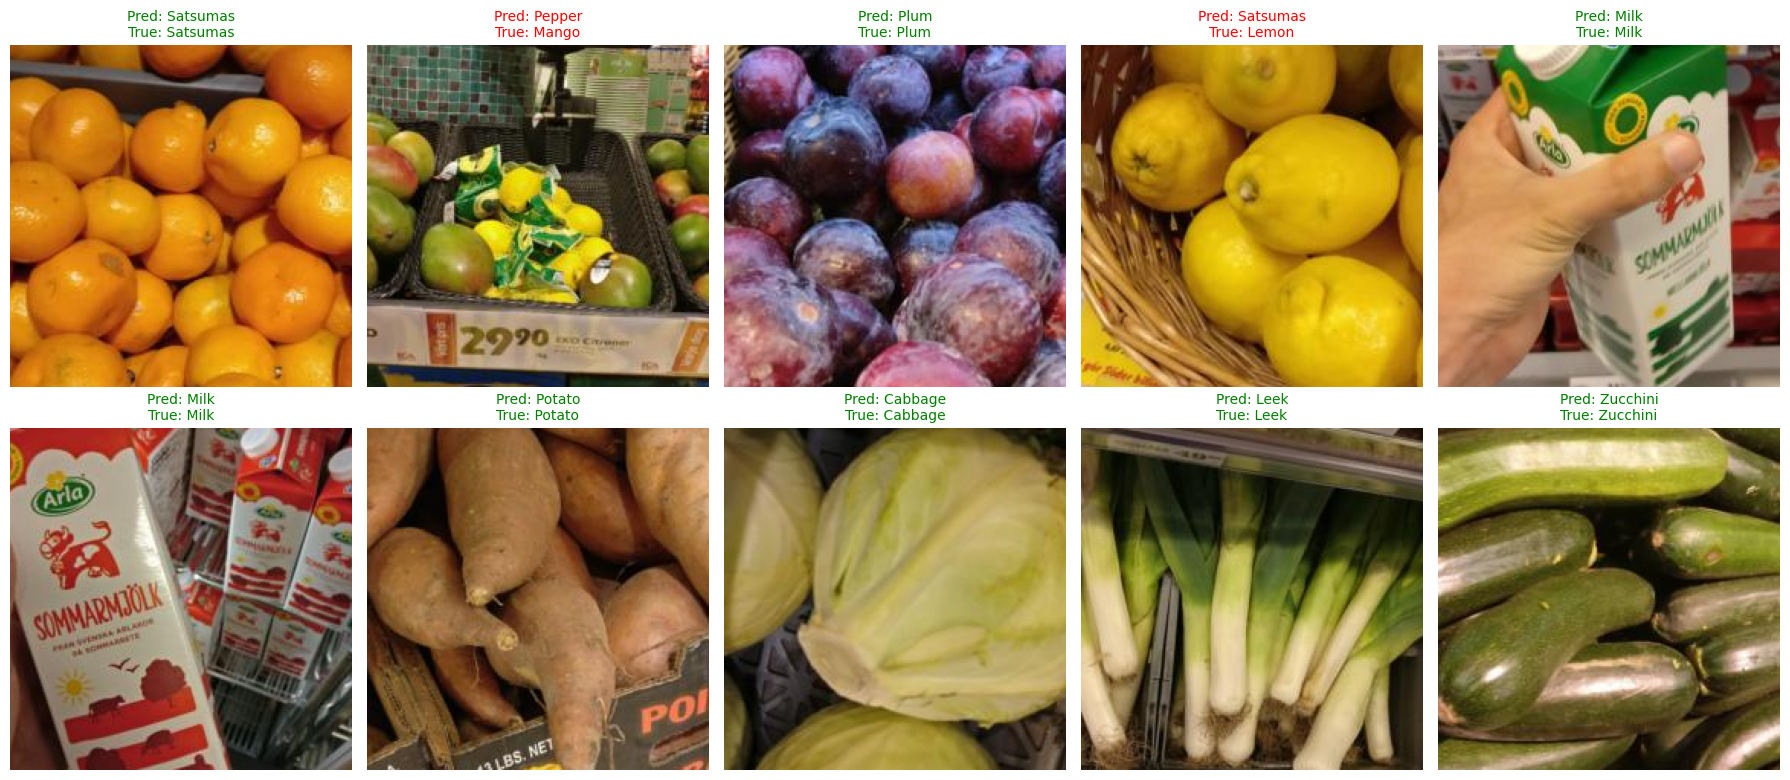

In [55]:
visualize_predictions(resnet18, test_dl)